In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# Statsmodels para AR-HMM
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

load_dotenv()

True

## 1. Carregamento dos Dados

In [2]:
# Carregar variáveis de ambiente
path_dados_tratados = os.getenv('PATH_DADOS_TRATADOS')

# Carregar indicadores contábeis
resultado_bruto = pd.read_csv(f"{path_dados_tratados}resultado_bruto.csv", index_col=0, parse_dates=True)
lucro_consolidado = pd.read_csv(f"{path_dados_tratados}lucro_consolidado.csv", index_col=0, parse_dates=True)
despesas_operacionais = pd.read_csv(f"{path_dados_tratados}despesas_operacionais.csv", index_col=0, parse_dates=True)

print("Empresas disponíveis:", resultado_bruto.columns.tolist())
print("\nPeríodo:", resultado_bruto.index.min(), "até", resultado_bruto.index.max())
print("Número de observações:", len(resultado_bruto))

Empresas disponíveis: ['2437', '18376', '20257', '21490']

Período: 2010-03-31 00:00:00 até 2024-09-30 00:00:00
Número de observações: 59


## 2. Análise Exploratória: Autocorrelação e Estacionariedade


ANÁLISE EXPLORATÓRIA - Resultado Bruto - Empresa 21490

--- Estatísticas Descritivas ---
Média: 664665974.58
Desvio Padrão: 445462440.84
Min/Max: 268152000.00 / 2405519000.00
Coef. Variação: 67.02%

--- Teste ADF (H0: série tem raiz unitária - NÃO estacionária) ---
Estatística: -2.2098
P-value: 0.2027
Conclusão ADF: Série NÃO estacionária ✗ (não rejeita H0)

--- Teste KPSS (H0: série é estacionária) ---
Estatística: 0.8167
P-value: 0.0100
Conclusão KPSS: Série NÃO estacionária ✗ (rejeita H0)

--- Conclusão Combinada (ADF + KPSS) ---
✗✗ Série NÃO ESTACIONÁRIA (ambos os testes concordam)
   → Recomendação: Aplicar transformação (log returns, diferenciação)

--- Autocorrelação ---
ACF(1): 0.8377
ACF(2): 0.7396
PACF(1): 0.8522
PACF(2): 0.1438

Ordem AR sugerida: 1


C:\Users\giova\AppData\Local\Temp\ipykernel_3060\2198181678.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(serie_limpa, regression='c', nlags='auto')


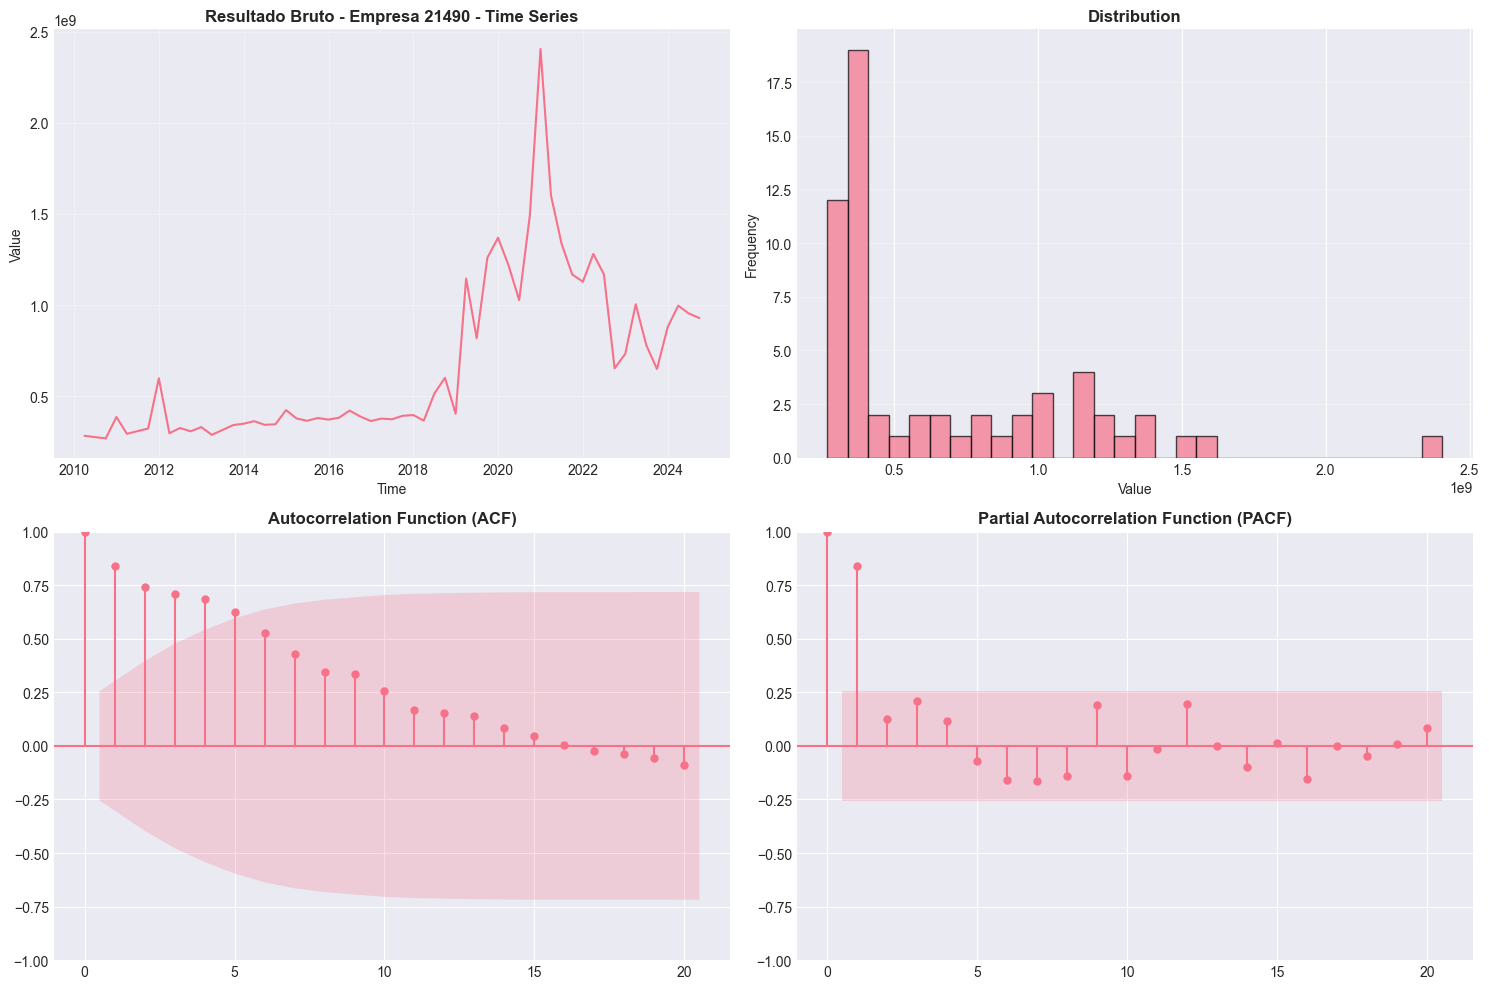

In [4]:
def analisar_serie_ar(serie, nome='Série'):
    """
    Análise exploratória para identificar se AR-HMM é apropriado:
    1. Testes de estacionariedade (ADF + KPSS)
    2. ACF/PACF para identificar ordem AR
    3. Estatísticas descritivas
    """
    # Limpa série
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    print(f"\n{'='*70}")
    print(f"ANÁLISE EXPLORATÓRIA - {nome}")
    print('='*70)
    
    # 1. Estatísticas básicas
    print(f"\n--- Estatísticas Descritivas ---")
    print(f"Média: {serie_limpa.mean():.2f}")
    print(f"Desvio Padrão: {serie_limpa.std():.2f}")
    print(f"Min/Max: {serie_limpa.min():.2f} / {serie_limpa.max():.2f}")
    print(f"Coef. Variação: {serie_limpa.std() / serie_limpa.mean():.2%}")
    
    # 2. Testes de estacionariedade (ADF e KPSS)
    adf_result = adfuller(serie_limpa, autolag='AIC')
    print(f"\n--- Teste ADF (H0: série tem raiz unitária - NÃO estacionária) ---")
    print(f"Estatística: {adf_result[0]:.4f}")
    print(f"P-value: {adf_result[1]:.4f}")
    print(f"Conclusão ADF: {'Série ESTACIONÁRIA ✓ (rejeita H0)' if adf_result[1] < 0.05 else 'Série NÃO estacionária ✗ (não rejeita H0)'}")
    
    kpss_result = kpss(serie_limpa, regression='c', nlags='auto')
    print(f"\n--- Teste KPSS (H0: série é estacionária) ---")
    print(f"Estatística: {kpss_result[0]:.4f}")
    print(f"P-value: {kpss_result[1]:.4f}")
    print(f"Conclusão KPSS: {'Série ESTACIONÁRIA ✓ (não rejeita H0)' if kpss_result[1] > 0.05 else 'Série NÃO estacionária ✗ (rejeita H0)'}")
    
    # Conclusão combinada
    estacionaria = (adf_result[1] < 0.05) and (kpss_result[1] > 0.05)
    print(f"\n--- Conclusão Combinada (ADF + KPSS) ---")
    if estacionaria:
        print("✓✓ Série ESTACIONÁRIA (ambos os testes concordam)")
    elif adf_result[1] < 0.05 and kpss_result[1] <= 0.05:
        print("⚠ Resultados CONFLITANTES (ADF=estacionária, KPSS=não estacionária)")
    elif adf_result[1] >= 0.05 and kpss_result[1] > 0.05:
        print("⚠ Resultados CONFLITANTES (ADF=não estacionária, KPSS=estacionária)")
    else:
        print("✗✗ Série NÃO ESTACIONÁRIA (ambos os testes concordam)")
        print("   → Recomendação: Aplicar transformação (log returns, diferenciação)")
    
    # 3. Autocorrelação
    acf_values = acf(serie_limpa, nlags=12)
    pacf_values = pacf(serie_limpa, nlags=12)
    
    print(f"\n--- Autocorrelação ---")
    print(f"ACF(1): {acf_values[1]:.4f}")
    print(f"ACF(2): {acf_values[2]:.4f}")
    print(f"PACF(1): {pacf_values[1]:.4f}")
    print(f"PACF(2): {pacf_values[2]:.4f}")
    
    # Sugestão de ordem AR
    if abs(pacf_values[1]) > 0.2 and abs(pacf_values[2]) < 0.2:
        ordem_sugerida = 1
    elif abs(pacf_values[2]) > 0.2:
        ordem_sugerida = 2
    else:
        ordem_sugerida = 1
    
    print(f"\nOrdem AR sugerida: {ordem_sugerida}")
    
    # 4. Gráficos
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Série temporal
    axes[0, 0].plot(serie_limpa.index, serie_limpa.values, linewidth=1.5)
    axes[0, 0].set_title(f'{nome} - Time Series', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Histograma
    axes[0, 1].hist(serie_limpa.values, bins=30, edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # ACF
    plot_acf(serie_limpa, lags=20, ax=axes[1, 0])
    axes[1, 0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
    
    # PACF
    plot_pacf(serie_limpa, lags=20, ax=axes[1, 1])
    axes[1, 1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'serie_limpa': serie_limpa,
        'estacionaria': estacionaria,
        'adf_pvalue': adf_result[1],
        'kpss_pvalue': kpss_result[1],
        'acf_lag1': acf_values[1],
        'pacf_lag1': pacf_values[1],
        'ordem_ar_sugerida': ordem_sugerida
    }

# Exemplo: Análise para uma empresa
empresa_analise = '21490'
resultado_exploracao = analisar_serie_ar(
    resultado_bruto[empresa_analise],
    nome=f'Resultado Bruto - Empresa {empresa_analise}'
)

## 3. Implementação do AR-HMM (Markov Switching Autoregression)

### Configurações do Modelo
- `k_regimes`: Número de estados ocultos (2 ou 3)
- `order`: Ordem do processo autoregressivo (1 para AR(1), 2 para AR(2))
- `switching_trend=True`: Intercepto varia por regime (μ_s)
- `switching_ar=True`: Coeficiente AR varia por regime (φ_s)
- `switching_variance=True`: Variância varia por regime (σ²_s)

In [3]:
def treinar_ar_hmm(serie, nome_serie='Série', k_regimes=3, order=1, 
                   switching_trend=True, switching_ar=True, switching_variance=True,
                   em_iter=500, search_reps=20, usar_log_returns=True):
    """
    Treina modelo AR-HMM (Markov Switching Autoregression)
    
    Args:
        serie: série temporal original
        nome_serie: nome descritivo
        k_regimes: número de estados ocultos (2 ou 3)
        order: ordem AR (1 para AR(1), 2 para AR(2))
        switching_trend: intercepto varia por regime
        switching_ar: coeficiente AR varia por regime
        switching_variance: variância varia por regime
        em_iter: iterações do algoritmo EM
        search_reps: repetições de busca para inicialização
        usar_log_returns: se True, aplica log returns para estacionariedade
    
    Returns:
        dict com modelo treinado e resultados
    """
    # Limpa série
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    # Armazena série original
    serie_original = serie_limpa.copy()
    
    # Aplica log returns se solicitado
    if usar_log_returns:
        print(f"\n{'='*70}")
        print(f"TRANSFORMAÇÃO PARA ESTACIONARIEDADE")
        print('='*70)
        print(f"Aplicando LOG RETURNS: r_t = log(y_t / y_(t-1))")
        
        # Verifica valores não positivos
        valores_nao_positivos = (serie_limpa <= 0).sum()
        if valores_nao_positivos > 0:
            print(f"⚠ Aviso: {valores_nao_positivos} valores não positivos encontrados")
            print(f"  Ajustando: somando constante para tornar todos positivos")
            min_val = serie_limpa.min()
            if min_val <= 0:
                serie_limpa = serie_limpa + abs(min_val) + 1
        
        # Calcula log returns
        serie_limpa = np.log(serie_limpa / serie_limpa.shift(1)).dropna()
        print(f"  Observações antes: {len(serie_original)}")
        print(f"  Observações depois: {len(serie_limpa)} (perde 1 observação)")
        
        # Verifica estacionariedade após transformação
        adf_result = adfuller(serie_limpa, autolag='AIC')
        kpss_result = kpss(serie_limpa, regression='c', nlags='auto')
        
        print(f"\n--- Verificação de Estacionariedade (Série Transformada) ---")
        print(f"ADF p-value: {adf_result[1]:.4f} {'✓ estacionária' if adf_result[1] < 0.05 else '✗ não estacionária'}")
        print(f"KPSS p-value: {kpss_result[1]:.4f} {'✓ estacionária' if kpss_result[1] > 0.05 else '✗ não estacionária'}")
        
        if adf_result[1] < 0.05 and kpss_result[1] > 0.05:
            print("✓✓ Série transformada é ESTACIONÁRIA (ambos os testes)")
        else:
            print("⚠ Aviso: Série transformada pode não ser totalmente estacionária")
    
    print(f"\n{'='*70}")
    print(f"TREINAMENTO AR-HMM - {nome_serie}")
    print('='*70)
    print(f"Configuração:")
    print(f"  - Regimes: {k_regimes}")
    print(f"  - Ordem AR: {order}")
    print(f"  - Switching: trend={switching_trend}, ar={switching_ar}, variance={switching_variance}")
    print(f"  - Observações: {len(serie_limpa)}")
    
    # Cria modelo AR-HMM
    mod = MarkovAutoregression(
        serie_limpa.values,
        k_regimes=k_regimes,
        order=order,
        trend='c',  # intercepto constante (varia por regime se switching_trend=True)
        switching_trend=switching_trend,
        switching_ar=switching_ar,
        switching_variance=switching_variance
    )
    
    # Ajuste do modelo (EM + otimização)
    print(f"\nIniciando ajuste... (pode levar alguns minutos)")
    try:
        res = mod.fit(em_iter=em_iter, search_reps=search_reps, disp=False)
        print("✓ Modelo convergiu com sucesso!")
        convergiu = True
    except Exception as e:
        print(f"✗ Erro no ajuste: {e}")
        return None
    
    # Extrai resultados
    smoothed_probs = res.smoothed_marginal_probabilities  # P(regime | todos os dados)
    filtered_probs = res.filtered_marginal_probabilities  # P(regime | dados até t)
    estados_preditos = np.argmax(smoothed_probs, axis=1)  # Regime mais provável
    
    # Log-likelihood e critérios de informação
    log_likelihood = res.llf
    aic = res.aic
    bic = res.bic
    
    print(f"\n--- Critérios de Ajuste ---")
    print(f"Log-Likelihood: {log_likelihood:.2f}")
    print(f"AIC: {aic:.2f}")
    print(f"BIC: {bic:.2f}")
    
    # Parâmetros estimados por regime
    print(f"\n--- Parâmetros Estimados por Regime ---")
    
    # Resumo completo do modelo
    print(f"\n{res.summary()}")
    
    # Extração manual dos parâmetros (statsmodels organiza diferente por modelo)
    # Para MarkovAutoregression, os parâmetros vêm em grupos
    try:
        for regime in range(k_regimes):
            print(f"\n  Regime {regime}:")
            
            # Intercepto (trend) - índice depende da estrutura
            if switching_trend:
                param_name = f'const[{regime}]'
                if hasattr(res, 'params') and isinstance(res.params, pd.Series):
                    if param_name in res.params.index:
                        intercepto = res.params[param_name]
                        print(f"    Intercepto (μ): {intercepto:.4f}")
            
            # Coeficientes AR
            if switching_ar:
                for lag in range(1, order + 1):
                    param_name = f'y.L{lag}[{regime}]'
                    if hasattr(res, 'params') and isinstance(res.params, pd.Series):
                        if param_name in res.params.index:
                            coef_ar = res.params[param_name]
                            print(f"    AR({lag}) (φ_{lag}): {coef_ar:.4f}")
            
            # Variância
            if switching_variance:
                param_name = f'sigma2[{regime}]'
                if hasattr(res, 'params') and isinstance(res.params, pd.Series):
                    if param_name in res.params.index:
                        variancia = res.params[param_name]
                        print(f"    Variância (σ²): {variancia:.4f}")
    except Exception as e:
        print(f"\n  ⚠ Erro ao extrair parâmetros detalhados: {e}")
        print("  Use res.summary() acima para visualizar todos os parâmetros.")
    
    # Matriz de transição
    print(f"\n--- Matriz de Transição (P_ij = P(regime j | regime i)) ---")
    print(res.regime_transition.round(3))
    
    # Duração esperada em cada regime
    print(f"\n--- Duração Esperada por Regime ---")
    for regime in range(k_regimes):
        duracao = res.expected_durations[regime]
        print(f"  Regime {regime}: {duracao:.2f} períodos")
    
    # Estatísticas por regime
    estatisticas_regimes = []
    for regime in range(k_regimes):
        mascara = estados_preditos == regime
        # Usar .values para evitar problema de índice pandas
        valores_regime = serie_limpa[1:].values[mascara]
        
        estatisticas_regimes.append({
            'regime': regime,
            'n_observacoes': mascara.sum(),
            'percentual': (mascara.sum() / len(serie_limpa[1:])) * 100,
            'media': valores_regime.mean(),
            'desvio_padrao': valores_regime.std(),
            'min': valores_regime.min(),
            'max': valores_regime.max()
        })
    
    print(f"\n--- Estatísticas Descritivas por Regime ---")
    df_stats = pd.DataFrame(estatisticas_regimes)
    print(df_stats.to_string(index=False))
    
    # IMPORTANTE: AR(order) usa 'order' observações como lag
    # Então os resultados começam da observação order+1
    # Para AR(1): primeira obs é usada como lag, resultados começam da segunda
    index_ajustado = serie_limpa.index[order:]  # Pula as primeiras 'order' observações
    serie_ajustada = serie_limpa.iloc[order:]   # Valores correspondentes

    return {
        'nome': nome_serie,
        'serie_limpa': serie_ajustada,  # Série alinhada com previsões
        'serie_completa': serie_limpa,   # Série transformada completa
        'serie_original': serie_original, # Série antes de transformações
        'index': index_ajustado,         # Índice alinhado
        'modelo': res,
        'convergiu': convergiu,
        'smoothed_probs': smoothed_probs,
        'filtered_probs': filtered_probs,
        'estados_preditos': estados_preditos,
        'log_likelihood': log_likelihood,
        'aic': aic,
        'bic': bic,
        'estatisticas_regimes': df_stats,
        'k_regimes': k_regimes,
        'order': order,
        'usar_log_returns': usar_log_returns
    }

### 3.1 Tratamento: Deixa série estacionária

In [4]:
# Exemplo: Treinar modelo AR(1)-HMM com log returns (série estacionária)
resultado_ar_hmm = treinar_ar_hmm(
    serie=resultado_bruto['18376'],
    nome_serie=f'Gross Income - Company {18376}',
    k_regimes=3,
    order=1,
    usar_log_returns=True  # Aplica log returns para estacionariedade
)


TRANSFORMAÇÃO PARA ESTACIONARIEDADE
Aplicando LOG RETURNS: r_t = log(y_t / y_(t-1))
  Observações antes: 59
  Observações depois: 58 (perde 1 observação)

--- Verificação de Estacionariedade (Série Transformada) ---
ADF p-value: 0.0000 ✓ estacionária
KPSS p-value: 0.1000 ✓ estacionária
✓✓ Série transformada é ESTACIONÁRIA (ambos os testes)

TREINAMENTO AR-HMM - Gross Income - Company 18376
Configuração:
  - Regimes: 3
  - Ordem AR: 1
  - Switching: trend=True, ar=True, variance=True
  - Observações: 58

Iniciando ajuste... (pode levar alguns minutos)


C:\Users\giova\AppData\Local\Temp\ipykernel_7432\1891071357.py:57: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_limpa, regression='c', nlags='auto')


✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: -17.43
AIC: 64.86
BIC: 95.51

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                 -17.431
Date:                  Sun, 22 Feb 2026   AIC                             64.862
Time:                          14:51:21   BIC                             95.508
Sample:                               0   HQIC                            76.772
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

## 4. Visualização de Estados

In [8]:
def plotar_resultados_ar_hmm(resultado, figsize=(16, 12)):
    """
    Plota resultados completos do AR-HMM:
    1. Série temporal com regimes
    2. Probabilidades suavizadas
    3. Probabilidades filtradas
    4. Distribuição por regime
    """
    if resultado is None:
        print("Resultado inválido. Modelo não convergiu.")
        return
    
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    fig.suptitle(f"{resultado['nome']} - AR-HMM Analysis", fontsize=14, fontweight='bold')
    
    k_regimes = resultado['k_regimes']
    cores = ['crimson', 'navy', 'darkgreen', 'purple', 'orange']
    
    # 1. Série temporal com regimes coloridos
    ax1 = axes[0]
    ax1.plot(resultado['index'], resultado['serie_limpa'].values, 
             color='gray', linewidth=1, alpha=0.5, label='Original Series')
    
    for regime in range(k_regimes):
        mascara = resultado['estados_preditos'] == regime
        # Usar .values para arrays numpy
        ax1.scatter(resultado['index'][mascara], 
                   resultado['serie_limpa'].values[mascara],
                   c=cores[regime], s=30, alpha=0.7, label=f'Regime {regime}')
    
    ax1.set_title('Time Series with Identified Regimes', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Value')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. Probabilidades suavizadas (smoothed) - usa todos os dados
    ax2 = axes[1]
    for regime in range(k_regimes):
        ax2.plot(resultado['index'], 
                resultado['smoothed_probs'][:, regime],
                label=f'P(Regime {regime} | y_1:T)',
                color=cores[regime],
                linewidth=2)
    
    ax2.set_title('Smoothed Probabilities - Using All Data', 
                 fontsize=12, fontweight='bold')
    ax2.set_ylabel('Probability')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # 3. Probabilidades filtradas (filtered) - usa dados até t
    ax3 = axes[2]
    for regime in range(k_regimes):
        ax3.plot(resultado['index'], 
                resultado['filtered_probs'][:, regime],
                label=f'P(Regime {regime} | y_1:t)',
                color=cores[regime],
                linewidth=2,
                linestyle='--')
    
    ax3.set_title('Filtered Probabilities - Using Data up to t (Real-time)', 
                 fontsize=12, fontweight='bold')
    ax3.set_ylabel('Probability')
    ax3.set_ylim(-0.05, 1.05)
    ax3.legend(loc='upper left', fontsize=10)
    ax3.grid(True, alpha=0.3)
    
    # 4. Histogramas por regime
    ax4 = axes[3]
    for regime in range(k_regimes):
        mascara = resultado['estados_preditos'] == regime
        # Usar .values para arrays numpy
        valores_regime = resultado['serie_limpa'].values[mascara]
        ax4.hist(valores_regime, bins=20, alpha=0.6, 
                label=f'Regime {regime} (n={mascara.sum()})',
                color=cores[regime],
                edgecolor='black')
    
    ax4.set_title('Value Distribution by Regime', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Value')
    ax4.set_ylabel('Frequency')
    ax4.legend(loc='upper right', fontsize=10)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()



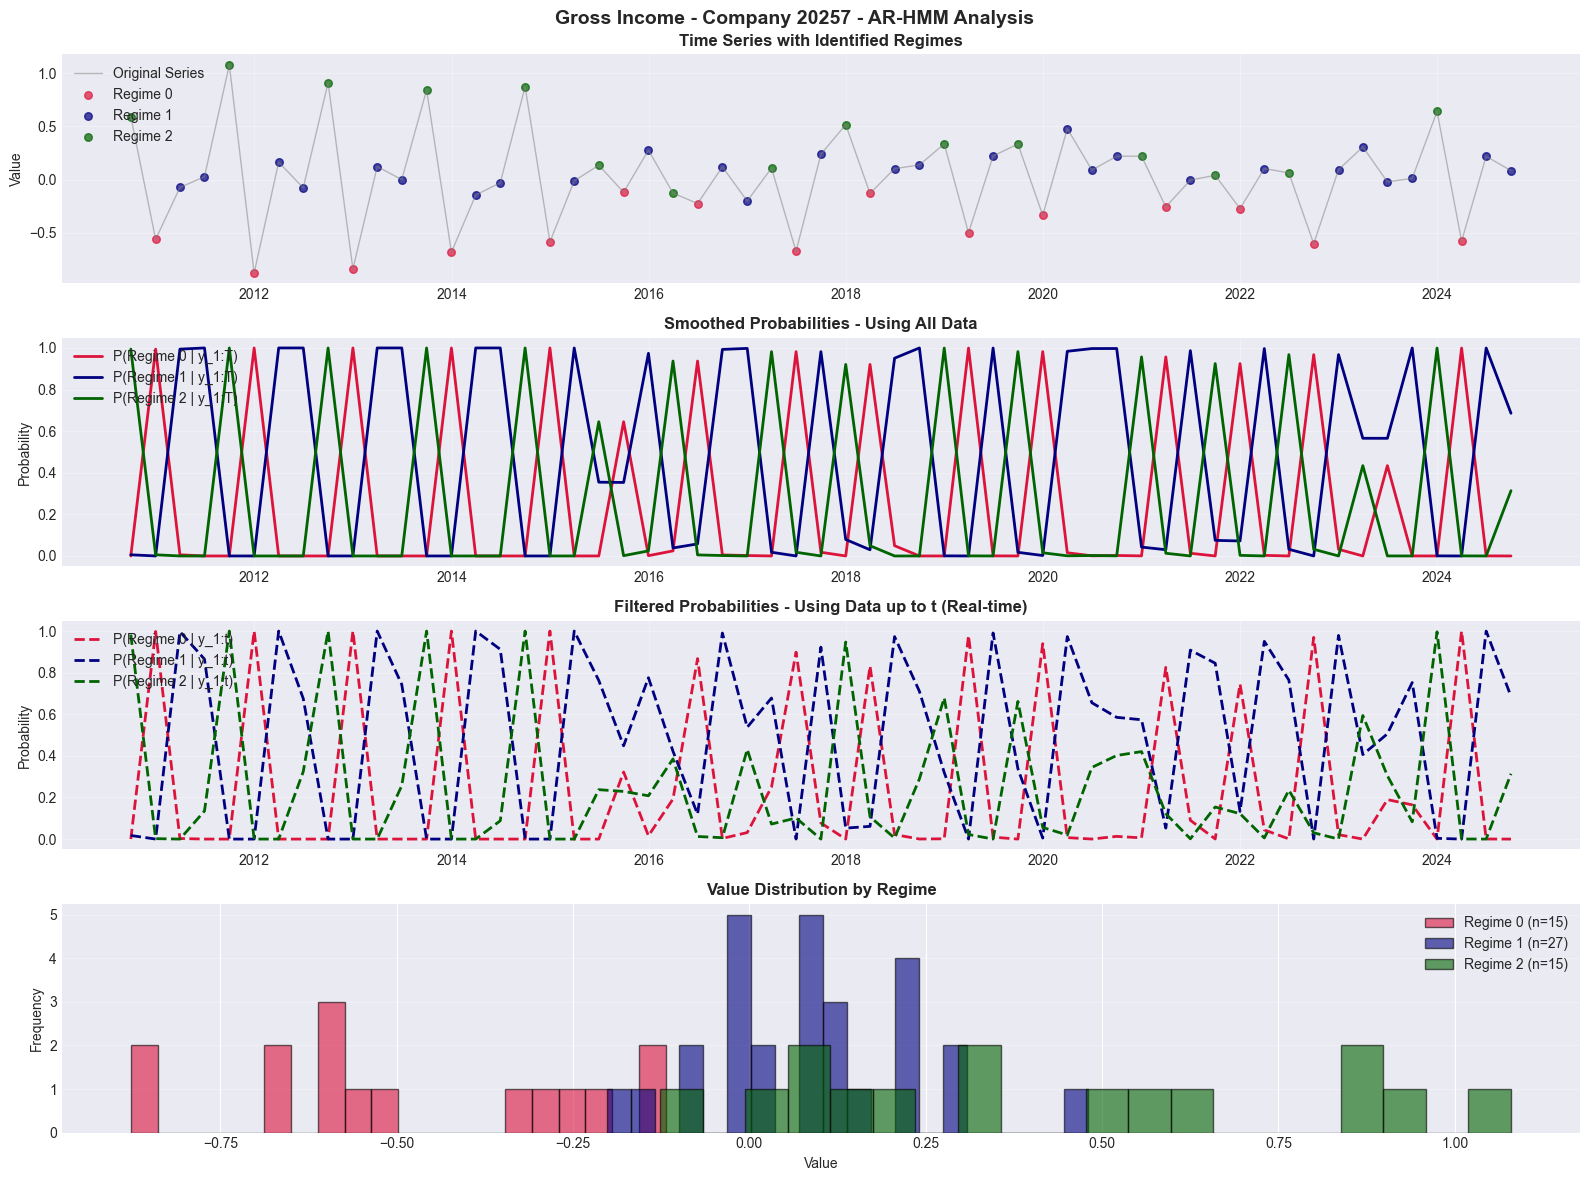

In [9]:
# Plotar resultados
if resultado_ar_hmm is not None:
    plotar_resultados_ar_hmm(resultado_ar_hmm)

## 5. Interpretação Econômica dos Regimes

In [56]:
def interpretar_regimes_ar_hmm(resultado):
    """
    Interpreta economicamente os regimes identificados pelo AR-HMM
    baseado nos parâmetros estimados (μ, φ, σ²)
    """
    if resultado is None:
        return
    
    print(f"\n{'='*70}")
    print(f"INTERPRETAÇÃO ECONÔMICA DOS REGIMES - {resultado['nome']}")
    print('='*70)
    
    modelo = resultado['modelo']
    k_regimes = resultado['k_regimes']
    
    interpretacoes = []
    
    for regime in range(k_regimes):
        # Extrai parâmetros (com verificação de tipo)
        try:
            if isinstance(modelo.params, pd.Series):
                intercepto = modelo.params[f'const[{regime}]']
                phi = modelo.params[f'y.L1[{regime}]']
                variancia = modelo.params[f'sigma2[{regime}]']
            else:
                # Se params não for Series, tenta acessar como array
                print(f"⚠ Formato de parâmetros inesperado. Pulando regime {regime}.")
                continue
        except (KeyError, IndexError) as e:
            print(f"⚠ Erro ao acessar parâmetros do regime {regime}: {e}")
            print(f"   Parâmetros disponíveis: {modelo.params.index.tolist() if hasattr(modelo.params, 'index') else 'N/A'}")
            continue
        
        # Estatísticas do regime
        mascara = resultado['estados_preditos'] == regime
        # Usar .values para evitar problema de índice pandas
        valores_regime = resultado['serie_limpa'].values[mascara]
        media_regime = valores_regime.mean()
        
        # Classificação econômica baseada em parâmetros
        print(f"\n{'='*70}")
        print(f"REGIME {regime}")
        print('='*70)
        
        print(f"\n--- Parâmetros do Modelo AR(1) ---")
        print(f"  μ (intercepto):    {intercepto:>10.4f}")
        print(f"  φ (persistência):  {phi:>10.4f}")
        print(f"  σ² (variância):    {variancia:>10.4f}")
        print(f"  σ (desvio padrão): {np.sqrt(variancia):>10.4f}")
        
        print(f"\n--- Características Observadas ---")
        print(f"  Valor médio:       {media_regime:>10.2f}")
        print(f"  N° observações:    {mascara.sum():>10d} ({mascara.sum()/len(mascara)*100:.1f}%)")
        
        # Interpretação do coeficiente φ (persistência)
        print(f"\n--- Interpretação da Persistência (φ) ---")
        if phi > 0.8:
            persistencia = "MUITO ALTA"
            desc_persistencia = "Shocks têm efeito prolongado. Crescimento ou crise persistentes."
        elif phi > 0.5:
            persistencia = "ALTA"
            desc_persistencia = "Tendências se mantêm por vários períodos."
        elif phi > 0.2:
            persistencia = "MODERADA"
            desc_persistencia = "Alguma memória, mas reversão à média em médio prazo."
        elif phi > 0:
            persistencia = "BAIXA"
            desc_persistencia = "Reversão rápida à média. Flutuações de curto prazo."
        else:
            persistencia = "NEGATIVA (Oscilação)"
            desc_persistencia = "Tendência de inversão. Comportamento cíclico."
        
        print(f"  Classificação: {persistencia}")
        print(f"  Descrição: {desc_persistencia}")
        
        # Interpretação da volatilidade (σ)
        print(f"\n--- Interpretação da Volatilidade (σ) ---")
        cv = np.sqrt(variancia) / abs(media_regime) if media_regime != 0 else np.nan
        if cv > 0.3:
            volatilidade = "ALTA"
            desc_volatilidade = "Incerteza elevada. Difícil previsão."
        elif cv > 0.15:
            volatilidade = "MODERADA"
            desc_volatilidade = "Variabilidade típica de indicadores contábeis."
        else:
            volatilidade = "BAIXA"
            desc_volatilidade = "Estabilidade. Previsibilidade elevada."
        
        print(f"  Coef. Variação: {cv:.2%}")
        print(f"  Classificação: {volatilidade}")
        print(f"  Descrição: {desc_volatilidade}")
        
        # Classificação econômica final
        print(f"\n--- CLASSIFICAÇÃO ECONÔMICA ---")
        # Usar série completa para mediana se disponível
        serie_ref = resultado.get('serie_completa', resultado['serie_limpa'])
        if media_regime > serie_ref.median() and phi > 0.5 and cv < 0.25:
            label = "🟢 CRESCIMENTO SUSTENTÁVEL"
            desc = "Alto valor médio + persistência + baixa volatilidade"
        elif media_regime > serie_ref.median() and phi > 0.5:
            label = "🟡 CRESCIMENTO VOLÁTIL"
            desc = "Alto valor médio + persistência + alta volatilidade"
        elif phi < 0.3 and cv > 0.25:
            label = "🔴 CRISE/INSTABILIDADE"
            desc = "Baixa persistência + alta volatilidade"
        elif media_regime < serie_ref.median():
            label = "🔵 CONTRAÇÃO"
            desc = "Valor médio abaixo da mediana"
        else:
            label = "⚪ ESTABILIDADE"
            desc = "Comportamento moderado em todas as dimensões"
        
        print(f"  {label}")
        print(f"  {desc}")
        
        interpretacoes.append({
            'regime': regime,
            'label': label,
            'persistencia': persistencia,
            'volatilidade': volatilidade,
            'phi': phi,
            'sigma': np.sqrt(variancia),
            'media': media_regime
        })
    
    return pd.DataFrame(interpretacoes)

# Interpretar regimes
if resultado_ar_hmm is not None:
    df_interpretacao = interpretar_regimes_ar_hmm(resultado_ar_hmm)
    print(f"\n\n{'='*70}")
    print("RESUMO COMPARATIVO DOS REGIMES")
    print('='*70)
    display(df_interpretacao)


INTERPRETAÇÃO ECONÔMICA DOS REGIMES - Gross Income - Company 21490
⚠ Formato de parâmetros inesperado. Pulando regime 0.
⚠ Formato de parâmetros inesperado. Pulando regime 1.
⚠ Formato de parâmetros inesperado. Pulando regime 2.


RESUMO COMPARATIVO DOS REGIMES


""


## 6. Validação One-Step-Ahead

In [6]:
def validacao_ar_hmm_one_step(serie, nome_serie='Série', k_regimes=2, order=1, 
                              janela_treino=50, usar_log_returns=True):
    """
    Validação one-step-ahead para AR-HMM
    Baseado no método treinar_ar_hmm para garantir consistência
    
    Args:
        serie: série temporal original
        nome_serie: nome descritivo
        k_regimes: número de regimes (recomendado: 2)
        order: ordem AR (1 para AR(1))
        janela_treino: tamanho da janela de treino (mínimo 50 recomendado)
        usar_log_returns: se True, aplica log returns para estacionariedade
    
    Returns:
        dict com previsões, valores reais e métricas
    """
    
    # ========== PASSO 1: Limpeza da série (igual ao treinar_ar_hmm) ==========
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    # Valida tamanho mínimo
    if len(serie_limpa) <= janela_treino + 10:
        print(f"✗ Série muito curta!")
        print(f"  Necessário: > {janela_treino + 10} observações")
        print(f"  Disponível: {len(serie_limpa)} observações")
        return None
    
    # ========== HEADER DE INFORMAÇÕES ==========
    print(f"\n{'='*70}")
    print(f"VALIDAÇÃO ONE-STEP-AHEAD AR-HMM - {nome_serie}")
    print('='*70)
    print(f"Configuração:")
    print(f"  - Série original: {len(serie_limpa)} observações")
    print(f"  - Janela de treino: {janela_treino}")
    print(f"  - Previsões out-of-sample: {len(serie_limpa) - janela_treino}")
    print(f"  - Regimes: {k_regimes} | Ordem AR: {order}")
    print(f"  - Transformação: {'Log Returns' if usar_log_returns else 'Valores Originais'}")
    
    # ========== PASSO 2: Armazena série original antes de transformações ==========
    serie_original_completa = serie_limpa.copy()
    
    # ========== PASSO 3: Aplica transformação log returns SE necessário ==========
    # (igual ao método treinar_ar_hmm)
    if usar_log_returns:
        print(f"\n--- Aplicando Log Returns ---")
        
        # Verifica e ajusta valores não positivos
        valores_nao_positivos = (serie_limpa <= 0).sum()
        if valores_nao_positivos > 0:
            print(f"  ⚠ {valores_nao_positivos} valores não positivos encontrados")
            min_val = serie_limpa.min()
            if min_val <= 0:
                ajuste = abs(min_val) + 1
                serie_limpa = serie_limpa + ajuste
                print(f"  ✓ Ajuste aplicado: +{ajuste:.2f}")
        
        # Calcula log returns
        serie_transformada = np.log(serie_limpa / serie_limpa.shift(1)).dropna()
        print(f"  ✓ Observações após transformação: {len(serie_transformada)}")
    else:
        serie_transformada = serie_limpa.copy()
    
    previsoes = []
    reais = []
    indices_pred = []
    n_sucessos = 0
    n_erros = 0
    
    # Loop de validação: treina com janela fixa, prevê próximo ponto
    for i in range(janela_treino, len(serie_transformada)):
        # ===== JANELA DE TREINO: Últimas 'janela_treino' observações =====
        inicio = i - janela_treino
        treino_dados = serie_transformada.iloc[inicio:i].values
        
        # ===== VALOR REAL (próxima observação após janela) =====
        real = serie_transformada.iloc[i]
        
        # ===== TREINA MODELO AR-HMM (mesma estrutura do treinar_ar_hmm) =====
        mod = MarkovAutoregression(
            treino_dados,
            k_regimes=k_regimes,
            order=order,
            trend='c',
            switching_trend=True,
            switching_ar=True,
            switching_variance=True
        )
        
        # Fit com parâmetros conservadores para convergência rápida
        res = mod.fit(
            em_iter=5000,          # Muito reduzido
            search_reps=20,      # Apenas 1 inicialização
            disp=False
        )
        
        # ===== PREVISÃO ONE-STEP-AHEAD =====
        # NOTA: res.forecast() não está implementado para MarkovAutoregression
        # Fazemos previsão manual usando as probabilidades filtradas e parâmetros
        
        # Probabilidades do regime no último ponto (filtered probabilities)
        regime_probs = res.filtered_marginal_probabilities[-1]  # P(regime | dados até t)
        
        # Último valor da série de treino (para AR(1))
        y_lag = treino_dados[-1]
        
        # Previsão ponderada por regime
        pred = 0.0
        for regime in range(k_regimes):
            # Extrai parâmetros do regime
            # Verifica se params é pd.Series ou array
            if isinstance(res.params, pd.Series):
                mu = res.params[f'const[{regime}]']  # Intercepto
                phi = res.params[f'y.L1[{regime}]']  # Coeficiente AR(1)
            else:
                # Se for array, usa indexação direta
                # Estrutura: [const[0], const[1], ..., y.L1[0], y.L1[1], ..., sigma2[0], sigma2[1], ..., p[0,0], p[0,1], ...]
                mu = res.params[regime]  # Intercepto do regime
                phi = res.params[k_regimes + regime]  # Coef AR(1) do regime
            
            # Previsão para este regime: y_t+1 = μ + φ * y_t
            pred_regime = mu + phi * y_lag
            
            # Pondera pela probabilidade do regime
            pred += regime_probs[regime] * pred_regime
        
        # ===== ARMAZENA RESULTADOS =====
        previsoes.append(pred)
        reais.append(real)
        indices_pred.append(serie_transformada.index[i])
        n_sucessos += 1
        
        # Progress report a cada 10 previsões
        if n_sucessos % 10 == 0:
            print(f"  ✓ Previsão {n_sucessos}/{len(serie_transformada)-janela_treino}")

    # ========== PASSO 5: Validação de resultados ==========
    if len(previsoes) == 0:
        print(f"\n✗ FALHA: Nenhuma previsão realizada!")
        print(f"  Modelo não convergiu em nenhuma iteração.")
        print(f"  Recomendações:")
        print(f"  - Aumentar janela_treino (atual: {janela_treino})")
        print(f"  - Verificar qualidade dos dados")
        return None
    
    # Taxa de sucesso
    taxa_sucesso = n_sucessos / (len(serie_transformada) - janela_treino)
    print(f"\n--- Resumo de Convergência ---")
    print(f"  Sucessos: {n_sucessos}/{len(serie_transformada)-janela_treino} ({taxa_sucesso*100:.1f}%)")
    print(f"  Erros: {n_erros}")
    
    if taxa_sucesso < 0.5:
        print(f"  ⚠ Taxa de sucesso baixa! Considere aumentar janela_treino.")
    
    # ========== PASSO 6: Cálculo de métricas ==========
    previsoes_arr = np.array(previsoes)
    reais_arr = np.array(reais)
    
    mse = mean_squared_error(reais_arr, previsoes_arr)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(reais_arr, previsoes_arr)
    
    # NRMSE normalizado pela faixa
    faixa = reais_arr.max() - reais_arr.min()
    nrmse = rmse / faixa if faixa > 0 else np.nan
    
    # Correlação
    if len(previsoes_arr) > 1:
        correlacao = np.corrcoef(reais_arr, previsoes_arr)[0, 1]
    else:
        correlacao = np.nan
    
    print(f"\n{'='*70}")
    print("MÉTRICAS DE VALIDAÇÃO")
    print('='*70)
    print(f"MSE:         {mse:.6f}")
    print(f"RMSE:        {rmse:.6f}")
    print(f"NRMSE:       {nrmse:.4f} (normalizado pela faixa)")
    print(f"MAE:         {mae:.6f}")
    print(f"Correlação:  {correlacao:.4f}")
    
    if usar_log_returns:
        print(f"\n⚠ Nota: Métricas calculadas sobre LOG RETURNS")
        print(f"  Para valores originais, aplicar exp(valor)")
    
    # ========== PASSO 7: Visualização ==========
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Gráfico 1: Série temporal
    axes[0].plot(indices_pred, reais, 'o-', label='Actual', 
                color='steelblue', linewidth=2, markersize=5, alpha=0.7)
    axes[0].plot(indices_pred, previsoes, 's--', label='Predicted', 
                color='crimson', linewidth=2, markersize=5, alpha=0.7)
    
    titulo = f'{nome_serie} - One-Step-Ahead Validation'
    if usar_log_returns:
        titulo += ' (Log Returns)'
    axes[0].set_title(titulo, fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Value')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Adiciona métricas no gráfico
    textstr = f'NRMSE: {nrmse:.4f}\nCorr: {correlacao:.4f}\nN: {n_sucessos}'
    axes[0].text(0.02, 0.98, textstr, transform=axes[0].transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Gráfico 2: Scatter plot
    axes[1].scatter(reais, previsoes, alpha=0.6, s=50, edgecolors='black')
    
    # Linha perfeita
    min_val = min(reais_arr.min(), previsoes_arr.min())
    max_val = max(reais_arr.max(), previsoes_arr.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 
                'r--', linewidth=2, label='Perfect Prediction')
    
    axes[1].set_xlabel('Actual Value')
    axes[1].set_ylabel('Predicted Value')
    axes[1].set_title(f'Actual vs Predicted | Correlation={correlacao:.4f}', 
                     fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ========== PASSO 8: Retorna resultados ==========
    return {
        'previsoes': previsoes_arr,
        'reais': reais_arr,
        'indices': indices_pred,
        'mse': mse,
        'rmse': rmse,
        'nrmse': nrmse,
        'mae': mae,
        'correlacao': correlacao,
        'n_sucessos': n_sucessos,
        'n_erros': n_erros,
        'taxa_sucesso': taxa_sucesso,
        'janela_treino': janela_treino,
        'usar_log_returns': usar_log_returns
    }


VALIDAÇÃO ONE-STEP-AHEAD AR-HMM - Resultado Bruto - Empresa 18376
Configuração:
  - Série original: 59 observações
  - Janela de treino: 45
  - Previsões out-of-sample: 14
  - Regimes: 2 | Ordem AR: 1
  - Transformação: Log Returns

--- Aplicando Log Returns ---
  ✓ Observações após transformação: 58
  ✓ Previsão 10/13

--- Resumo de Convergência ---
  Sucessos: 13/13 (100.0%)
  Erros: 0

MÉTRICAS DE VALIDAÇÃO
MSE:         0.733396
RMSE:        0.856385
NRMSE:       1.4833 (normalizado pela faixa)
MAE:         0.810260
Correlação:  -0.1540

⚠ Nota: Métricas calculadas sobre LOG RETURNS
  Para valores originais, aplicar exp(valor)


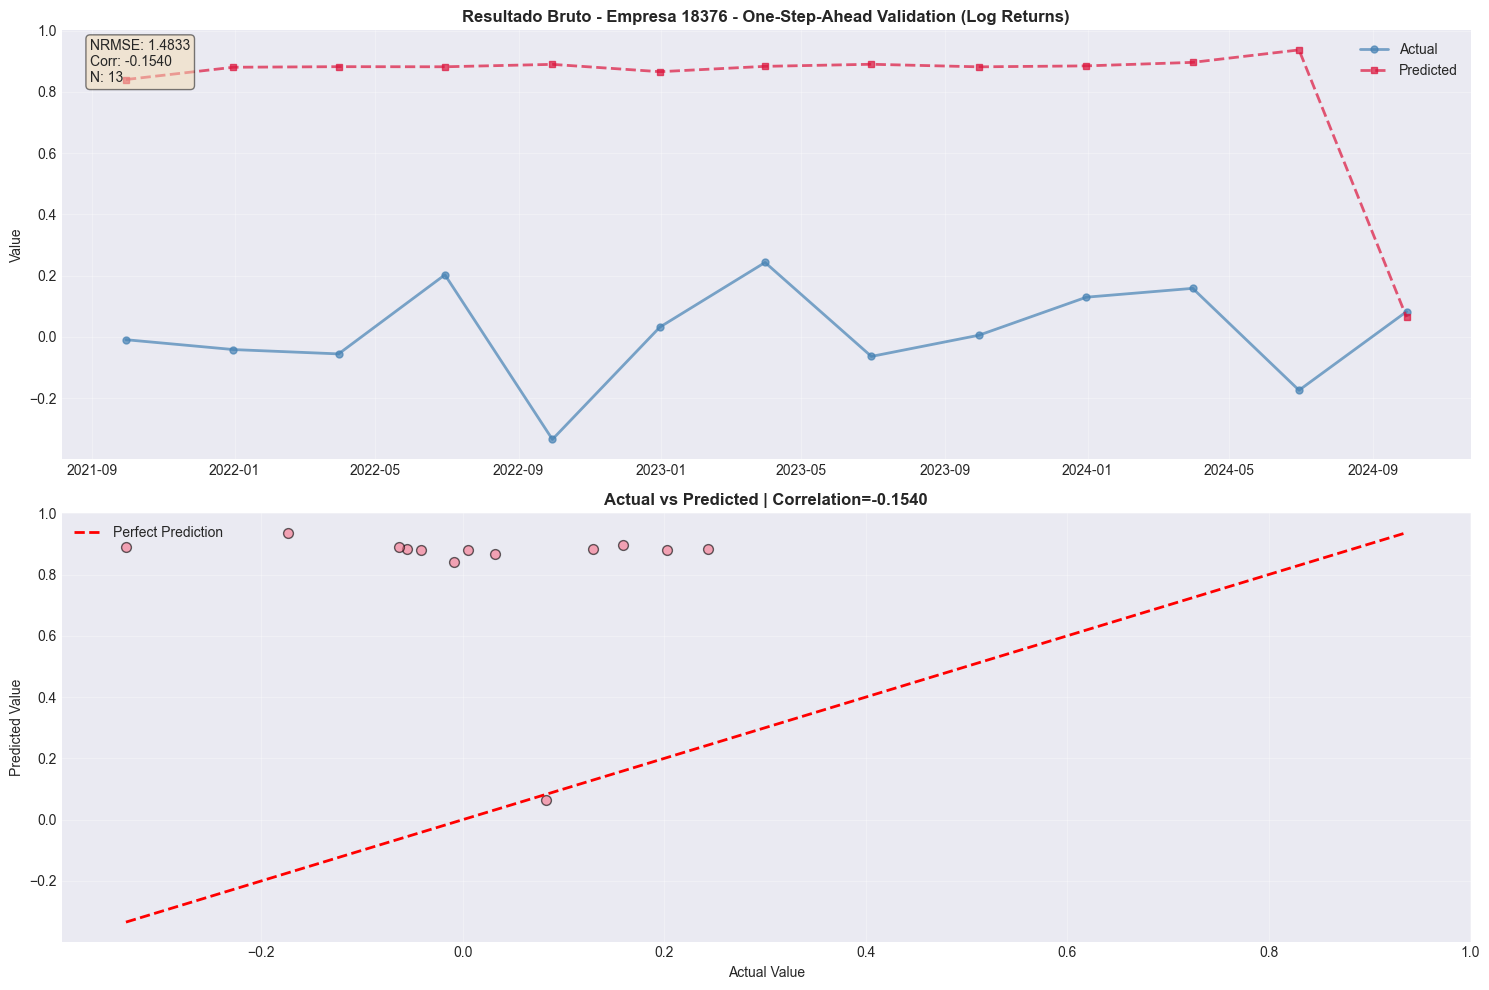

In [8]:
empresa_analise = '18376'
resultado_validacao = validacao_ar_hmm_one_step(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Resultado Bruto - Empresa {empresa_analise}',
    k_regimes=2,
    order=1,
    janela_treino=45,  # Janela maior para melhor convergência
    usar_log_returns=True
)


VALIDAÇÃO ONE-STEP-AHEAD AR-HMM - Gross Income - Company 18376
Configuração:
  - Série original: 59 observações
  - Janela de treino: 45
  - Previsões out-of-sample: 14
  - Regimes: 3 | Ordem AR: 1
  - Transformação: Log Returns

--- Aplicando Log Returns ---
  ✓ Observações após transformação: 58


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: Es

  ✓ Previsão 10/13


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: Es


--- Resumo de Convergência ---
  Sucessos: 13/13 (100.0%)
  Erros: 0

MÉTRICAS DE VALIDAÇÃO
MSE:         0.266996
RMSE:        0.516716
NRMSE:       0.8949 (normalizado pela faixa)
MAE:         0.476183
Correlação:  0.4986

⚠ Nota: Métricas calculadas sobre LOG RETURNS
  Para valores originais, aplicar exp(valor)


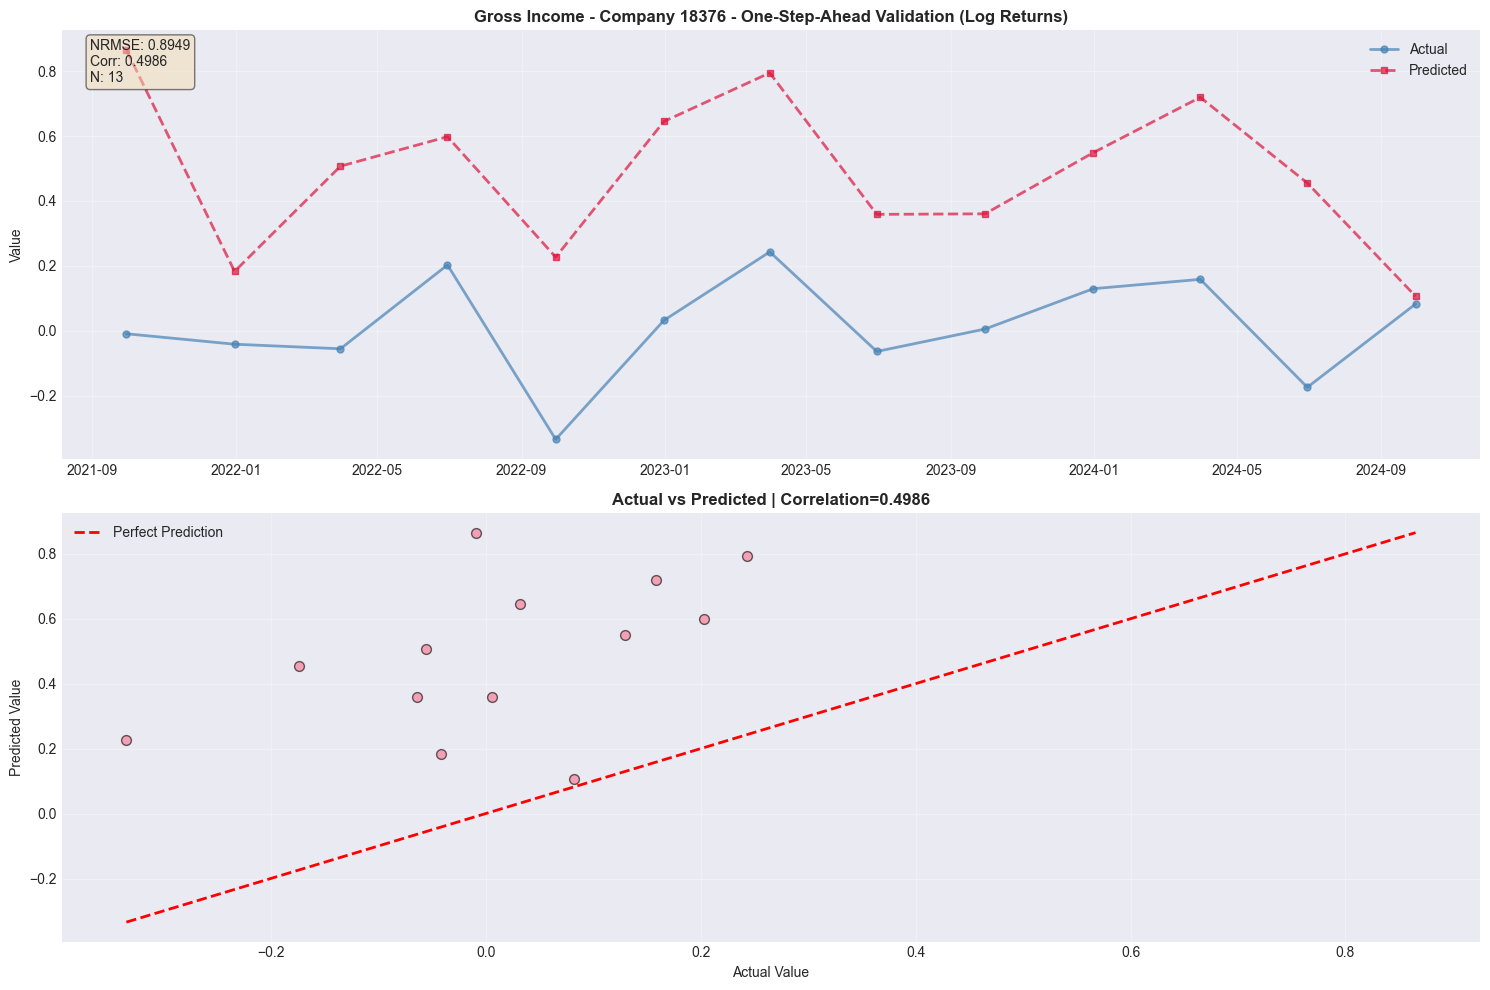

In [9]:
# Validação com novo método
resultado_validacao = validacao_ar_hmm_one_step(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    k_regimes=3,
    order=1,
    janela_treino=45,  # Janela maior para melhor convergência
    usar_log_returns=True
)

In [49]:
# Validação com novo método
resultado_validacao = validacao_ar_hmm_one_step(
    serie=despesas_operacionais[empresa_analise],
    nome_serie=f'Operational Expenses - Company {empresa_analise}',
    k_regimes=2,
    order=1,
    janela_treino=45,  # Janela maior para melhor convergência
    usar_log_returns=True
)


VALIDAÇÃO ONE-STEP-AHEAD AR-HMM - Operational Expenses - Company 21490
Configuração:
  - Série original: 59 observações
  - Janela de treino: 46
  - Previsões out-of-sample: 13
  - Regimes: 2 | Ordem AR: 1
  - Transformação: Log Returns

--- Aplicando Log Returns ---
  ⚠ 52 valores não positivos encontrados
  ✓ Ajuste aplicado: +173367001.00
  ✓ Observações após transformação: 58


LinAlgError: SVD did not converge


VALIDAÇÃO ONE-STEP-AHEAD AR-HMM - Gross Profit - Company 21490
Configuração:
  - Série original: 59 observações
  - Janela de treino: 45
  - Previsões out-of-sample: 14
  - Regimes: 3 | Ordem AR: 1
  - Transformação: Log Returns

--- Aplicando Log Returns ---
  ✓ Observações após transformação: 58


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: Es

  ✓ Previsão 10/13


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Resumo de Convergência ---
  Sucessos: 13/13 (100.0%)
  Erros: 0

MÉTRICAS DE VALIDAÇÃO
MSE:         0.366680
RMSE:        0.605541
NRMSE:       0.4225 (normalizado pela faixa)
MAE:         0.479098
Correlação:  -0.1256

⚠ Nota: Métricas calculadas sobre LOG RETURNS
  Para valores originais, aplicar exp(valor)


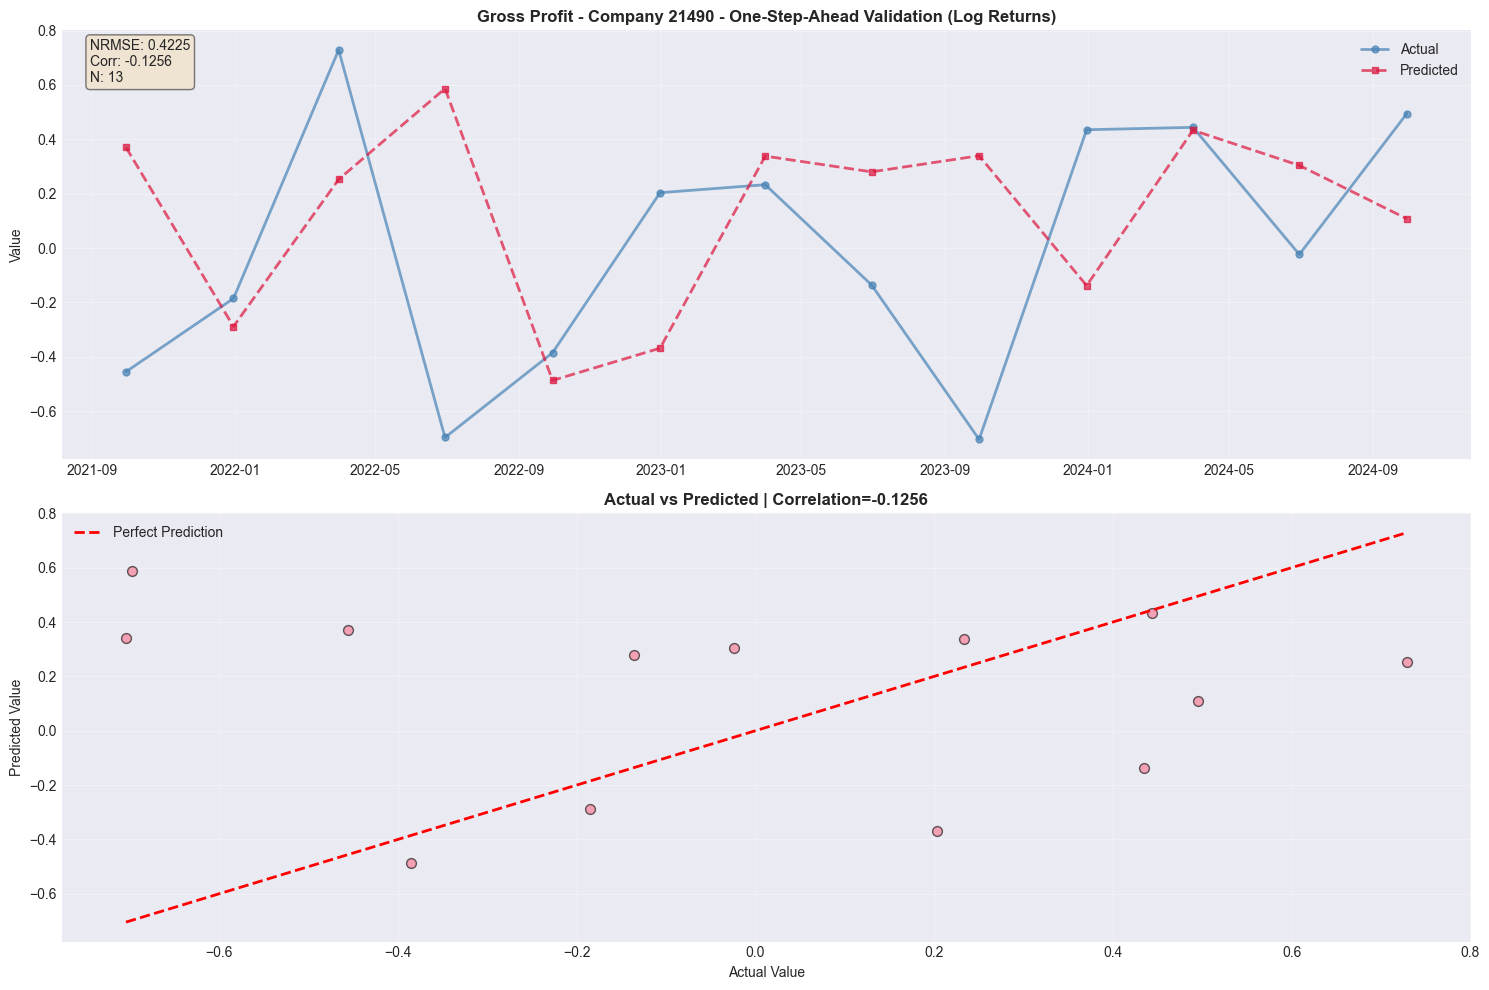

In [51]:
# Validação com novo método
resultado_validacao = validacao_ar_hmm_one_step(
    serie=lucro_consolidado[empresa_analise],
    nome_serie=f'Gross Profit - Company {empresa_analise}',
    k_regimes=3,
    order=1,
    janela_treino=45,  # Janela maior para melhor convergência
    usar_log_returns=True
)


## 7. Grid Search: Seleção de Hiperparâmetros (NRMSE-based)

In [10]:
def grid_search_ar_hmm_nrmse(serie, nome_serie='Series', janela_treino=50, 
                             k_regimes_range=(2, 4), order_range=(1, 3),
                             usar_log_returns=True):
    """
    Grid search para AR-HMM baseado em validação one-step-ahead com métrica NRMSE
    Similar ao método treinar_ar_hmm, mas testa diferentes configurações
    
    Args:
        serie: série temporal original
        nome_serie: nome descritivo
        janela_treino: tamanho da janela de treino para validação
        k_regimes_range: tuple (min, max) para número de regimes
        order_range: tuple (min, max) para ordem AR
        usar_log_returns: se True, aplica log returns para estacionariedade
    
    Returns:
        dict com resultados do grid search e melhor configuração
    """
    
    # ========== PASSO 1: Limpeza da série (igual ao treinar_ar_hmm) ==========
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    # Valida tamanho mínimo
    if len(serie_limpa) <= janela_treino + 10:
        print(f"✗ Série muito curta para grid search!")
        print(f"  Necessário: > {janela_treino + 10} observações")
        print(f"  Disponível: {len(serie_limpa)} observações")
        return None
    
    print(f"\n{'='*70}")
    print(f"GRID SEARCH AR-HMM (NRMSE) - {nome_serie}")
    print('='*70)
    print(f"Configuração:")
    print(f"  - Série: {len(serie_limpa)} observações")
    print(f"  - Janela de treino: {janela_treino}")
    print(f"  - Previsões out-of-sample: {len(serie_limpa) - janela_treino}")
    print(f"  - Regimes: {k_regimes_range[0]} a {k_regimes_range[1]-1}")
    print(f"  - Ordem AR: {order_range[0]} a {order_range[1]-1}")
    print(f"  - Transformação: {'Log Returns' if usar_log_returns else 'Valores Originais'}")
    print(f"  - Métrica: NRMSE (Normalized Root Mean Squared Error)")
    
    # ========== PASSO 2: Armazena série original ==========
    serie_original_completa = serie_limpa.copy()
    
    # ========== PASSO 3: Aplica transformação log returns SE necessário ==========
    if usar_log_returns:
        print(f"\n--- Aplicando Log Returns ---")
        
        # Verifica e ajusta valores não positivos
        valores_nao_positivos = (serie_limpa <= 0).sum()
        if valores_nao_positivos > 0:
            print(f"  ⚠ {valores_nao_positivos} valores não positivos encontrados")
            min_val = serie_limpa.min()
            if min_val <= 0:
                ajuste = abs(min_val) + 1
                serie_limpa = serie_limpa + ajuste
                print(f"  ✓ Ajuste aplicado: +{ajuste:.2f}")
        
        # Calcula log returns
        serie_transformada = np.log(serie_limpa / serie_limpa.shift(1)).dropna()
        print(f"  ✓ Observações após transformação: {len(serie_transformada)}")
    else:
        serie_transformada = serie_limpa.copy()
    
    # ========== PASSO 4: Grid Search com validação one-step-ahead ==========
    print(f"\n{'='*70}")
    print("INICIANDO GRID SEARCH")
    print('='*70)
    
    resultados = []
    
    for k_regimes in range(k_regimes_range[0], k_regimes_range[1]):
        for order in range(order_range[0], order_range[1]):
            print(f"\n--- Testando: k_regimes={k_regimes}, order={order} ---")
            
            try:
                # Validação one-step-ahead
                previsoes = []
                reais = []
                n_sucessos = 0
                n_erros = 0
                
                # Loop de validação
                for i in range(janela_treino, len(serie_transformada)):
                    inicio = i - janela_treino
                    treino_dados = serie_transformada.iloc[inicio:i].values
                    real = serie_transformada.iloc[i]
                    
                    try:
                        # Treina modelo
                        mod = MarkovAutoregression(
                            treino_dados,
                            k_regimes=k_regimes,
                            order=order,
                            trend='c',
                            switching_trend=True,
                            switching_ar=True,
                            switching_variance=True
                        )
                        
                        res = mod.fit(em_iter=100, search_reps=5, disp=False)
                        
                        # Previsão manual one-step-ahead
                        regime_probs = res.filtered_marginal_probabilities[-1]
                        
                        # Para AR(order), usa os últimos 'order' valores
                        if order == 1:
                            y_lags = [treino_dados[-1]]
                        else:
                            y_lags = [treino_dados[-(j+1)] for j in range(order)]
                        
                        pred = 0.0
                        for regime in range(k_regimes):
                            # Extrai parâmetros
                            if isinstance(res.params, pd.Series):
                                mu = res.params[f'const[{regime}]']
                                # Para AR(order), soma todos os coeficientes
                                pred_regime = mu
                                for lag in range(1, order + 1):
                                    phi = res.params[f'y.L{lag}[{regime}]']
                                    pred_regime += phi * y_lags[lag-1]
                            else:
                                mu = res.params[regime]
                                pred_regime = mu
                                for lag in range(1, order + 1):
                                    phi = res.params[k_regimes * lag + regime]
                                    pred_regime += phi * y_lags[lag-1]
                            
                            pred += regime_probs[regime] * pred_regime
                        
                        previsoes.append(pred)
                        reais.append(real)
                        n_sucessos += 1
                        
                    except Exception as e:
                        n_erros += 1
                        continue
                
                # Calcula métricas
                if len(previsoes) > 0:
                    previsoes_arr = np.array(previsoes)
                    reais_arr = np.array(reais)
                    
                    mse = mean_squared_error(reais_arr, previsoes_arr)
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(reais_arr, previsoes_arr)
                    
                    faixa = reais_arr.max() - reais_arr.min()
                    nrmse = rmse / faixa if faixa > 0 else np.nan
                    
                    if len(previsoes_arr) > 1:
                        correlacao = np.corrcoef(reais_arr, previsoes_arr)[0, 1]
                    else:
                        correlacao = np.nan
                    
                    taxa_sucesso = n_sucessos / (len(serie_transformada) - janela_treino)
                    
                    resultados.append({
                        'k_regimes': k_regimes,
                        'order': order,
                        'nrmse': nrmse,
                        'rmse': rmse,
                        'mae': mae,
                        'correlacao': correlacao,
                        'mse': mse,
                        'n_sucessos': n_sucessos,
                        'n_erros': n_erros,
                        'taxa_sucesso': taxa_sucesso,
                        'convergiu': True
                    })
                    
                    print(f"  ✓ NRMSE={nrmse:.4f} | Corr={correlacao:.4f} | Taxa sucesso={taxa_sucesso*100:.1f}%")
                else:
                    resultados.append({
                        'k_regimes': k_regimes,
                        'order': order,
                        'nrmse': np.nan,
                        'rmse': np.nan,
                        'mae': np.nan,
                        'correlacao': np.nan,
                        'mse': np.nan,
                        'n_sucessos': 0,
                        'n_erros': n_erros,
                        'taxa_sucesso': 0.0,
                        'convergiu': False
                    })
                    print(f"  ✗ Falha: nenhuma previsão realizada")
                    
            except Exception as e:
                print(f"  ✗ Erro: {e}")
                resultados.append({
                    'k_regimes': k_regimes,
                    'order': order,
                    'nrmse': np.nan,
                    'rmse': np.nan,
                    'mae': np.nan,
                    'correlacao': np.nan,
                    'mse': np.nan,
                    'n_sucessos': 0,
                    'n_erros': 0,
                    'taxa_sucesso': 0.0,
                    'convergiu': False
                })
    
    # ========== PASSO 5: Análise de resultados ==========
    df_resultados = pd.DataFrame(resultados)
    df_resultados_validos = df_resultados[df_resultados['convergiu'] & ~df_resultados['nrmse'].isna()]
    
    if len(df_resultados_validos) == 0:
        print("\n✗ Nenhuma configuração convergiu com sucesso!")
        return {'resultados': df_resultados, 'melhor': None}
    
    # Identifica melhor modelo (menor NRMSE)
    melhor_idx = df_resultados_validos['nrmse'].idxmin()
    melhor = df_resultados_validos.loc[melhor_idx]
    
    print(f"\n{'='*70}")
    print("MELHOR CONFIGURAÇÃO (menor NRMSE)")
    print('='*70)
    print(f"  Regimes: {int(melhor['k_regimes'])}")
    print(f"  Ordem AR: {int(melhor['order'])}")
    print(f"  NRMSE: {melhor['nrmse']:.4f}")
    print(f"  RMSE: {melhor['rmse']:.6f}")
    print(f"  MAE: {melhor['mae']:.6f}")
    print(f"  Correlação: {melhor['correlacao']:.4f}")
    print(f"  Taxa de sucesso: {melhor['taxa_sucesso']*100:.1f}%")
    
    # ========== PASSO 6: Visualização ==========
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'{nome_serie} - Grid Search Results (NRMSE)', fontsize=14, fontweight='bold')
    
    # Heatmap NRMSE
    pivot_nrmse = df_resultados_validos.pivot(index='k_regimes', columns='order', values='nrmse')
    sns.heatmap(pivot_nrmse, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[0, 0], 
                cbar_kws={'label': 'NRMSE'})
    axes[0, 0].set_title('NRMSE by Configuration (lower is better)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('AR Order')
    axes[0, 0].set_ylabel('Number of Regimes')
    
    # Heatmap Correlação
    pivot_corr = df_resultados_validos.pivot(index='k_regimes', columns='order', values='correlacao')
    sns.heatmap(pivot_corr, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[0, 1],
                cbar_kws={'label': 'Correlation'})
    axes[0, 1].set_title('Correlation by Configuration (higher is better)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('AR Order')
    axes[0, 1].set_ylabel('Number of Regimes')
    
    # Bar plot NRMSE
    df_resultados_validos['config'] = df_resultados_validos.apply(
        lambda row: f"R{int(row['k_regimes'])}O{int(row['order'])}", axis=1
    )
    df_resultados_validos.plot(x='config', y='nrmse', kind='bar', ax=axes[1, 0], 
                               color='steelblue', legend=False)
    axes[1, 0].set_title('NRMSE Comparison', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Configuration (R=Regimes, O=Order)')
    axes[1, 0].set_ylabel('NRMSE')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    axes[1, 0].axhline(y=melhor['nrmse'], color='red', linestyle='--', linewidth=2, label='Best')
    axes[1, 0].legend()
    
    # Taxa de sucesso
    df_resultados_validos.plot(x='config', y='taxa_sucesso', kind='bar', ax=axes[1, 1],
                               color='darkgreen', legend=False)
    axes[1, 1].set_title('Success Rate by Configuration', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Configuration (R=Regimes, O=Order)')
    axes[1, 1].set_ylabel('Success Rate')
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # ========== PASSO 7: Tabela resumo ==========
    print(f"\n{'='*70}")
    print("TABELA COMPLETA DE RESULTADOS")
    print('='*70)
    df_display = df_resultados_validos[['k_regimes', 'order', 'nrmse', 'rmse', 'mae', 
                                         'correlacao', 'taxa_sucesso']].sort_values('nrmse')
    print(df_display.to_string(index=False))
    
    return {
        'resultados': df_resultados,
        'resultados_validos': df_resultados_validos,
        'melhor': melhor.to_dict(),
        'tabela': df_display,
        'nome_serie': nome_serie,
        'janela_treino': janela_treino,
        'usar_log_returns': usar_log_returns
    }


def grid_search_ar_hmm(serie, nome_serie='Série', 
                       k_regimes_range=(2, 4), 
                       order_range=(1, 3)):
    """
    Grid search para AR-HMM testando diferentes configurações
    
    Args:
        serie: série temporal
        k_regimes_range: tuple (min, max) para número de regimes
        order_range: tuple (min, max) para ordem AR
    """
    # Limpa série
    serie_limpa = (
        serie
        .sort_index()
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    
    print(f"\n{'='*70}")
    print(f"GRID SEARCH AR-HMM - {nome_serie}")
    print('='*70)
    
    resultados = []
    
    for k_regimes in range(k_regimes_range[0], k_regimes_range[1]):
        for order in range(order_range[0], order_range[1]):
            print(f"\nTestando: k_regimes={k_regimes}, order={order}")
            
            try:
                # Treina modelo
                mod = MarkovAutoregression(
                    serie_limpa.values,
                    k_regimes=k_regimes,
                    order=order,
                    trend='c',
                    switching_trend=True,
                    switching_ar=True,
                    switching_variance=True
                )
                res = mod.fit(em_iter=5000, search_reps=20, disp=False)
                
                resultados.append({
                    'k_regimes': k_regimes,
                    'order': order,
                    'log_likelihood': res.llf,
                    'aic': res.aic,
                    'bic': res.bic,
                    'convergiu': True
                })
                
                print(f"  ✓ LL={res.llf:.2f}, AIC={res.aic:.2f}, BIC={res.bic:.2f}")
            
            except Exception as e:
                print(f"  ✗ Erro: {e}")
                resultados.append({
                    'k_regimes': k_regimes,
                    'order': order,
                    'log_likelihood': np.nan,
                    'aic': np.nan,
                    'bic': np.nan,
                    'convergiu': False
                })
    
    df_resultados = pd.DataFrame(resultados)
    df_resultados_validos = df_resultados[df_resultados['convergiu']]
    
    if len(df_resultados_validos) == 0:
        print("\nNenhum modelo convergiu!")
        return df_resultados
    
    # Identifica melhores modelos
    melhor_aic = df_resultados_validos.loc[df_resultados_validos['aic'].idxmin()]
    melhor_bic = df_resultados_validos.loc[df_resultados_validos['bic'].idxmin()]
    melhor_ll = df_resultados_validos.loc[df_resultados_validos['log_likelihood'].idxmax()]
    
    print(f"\n{'='*70}")
    print("MELHORES MODELOS")
    print('='*70)
    print(f"\n✓ Melhor AIC:")
    print(f"  Regimes: {int(melhor_aic['k_regimes'])}, Ordem AR: {int(melhor_aic['order'])}")
    print(f"  AIC: {melhor_aic['aic']:.2f}")
    
    print(f"\n✓ Melhor BIC:")
    print(f"  Regimes: {int(melhor_bic['k_regimes'])}, Ordem AR: {int(melhor_bic['order'])}")
    print(f"  BIC: {melhor_bic['bic']:.2f}")
    
    print(f"\n✓ Melhor Log-Likelihood:")
    print(f"  Regimes: {int(melhor_ll['k_regimes'])}, Ordem AR: {int(melhor_ll['order'])}")
    print(f"  LL: {melhor_ll['log_likelihood']:.2f}")
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # AIC por configuração
    pivot_aic = df_resultados_validos.pivot(index='k_regimes', columns='order', values='aic')
    sns.heatmap(pivot_aic, annot=True, fmt='.1f', cmap='YlOrRd_r', ax=axes[0])
    axes[0].set_title('AIC by Configuration', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('AR Order')
    axes[0].set_ylabel('Number of Regimes')
    
    # BIC por configuração
    pivot_bic = df_resultados_validos.pivot(index='k_regimes', columns='order', values='bic')
    sns.heatmap(pivot_bic, annot=True, fmt='.1f', cmap='YlGnBu_r', ax=axes[1])
    axes[1].set_title('BIC by Configuration', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('AR Order')
    axes[1].set_ylabel('Number of Regimes')
    
    plt.tight_layout()
    plt.show()
    
    return df_resultados

### 7.1 Grid Search com NRMSE (Novo Método)

Este método realiza grid search testando diferentes configurações de **k_regimes** (2-3) e **order** (1-2) usando validação **one-step-ahead** e a métrica **NRMSE** (Normalized Root Mean Squared Error) para comparação.

**Vantagens sobre o grid search tradicional:**
- ✓ Usa validação out-of-sample (mais realista)
- ✓ Métrica NRMSE normalizada (comparável entre séries)
- ✓ Considera taxa de convergência
- ✓ Visualização completa dos resultados


GRID SEARCH AR-HMM (NRMSE) - Gross Income - Company 18376
Configuração:
  - Série: 59 observações
  - Janela de treino: 35
  - Previsões out-of-sample: 24
  - Regimes: 2 a 3
  - Ordem AR: 1 a 2
  - Transformação: Log Returns
  - Métrica: NRMSE (Normalized Root Mean Squared Error)

--- Aplicando Log Returns ---
  ✓ Observações após transformação: 58

INICIANDO GRID SEARCH

--- Testando: k_regimes=2, order=1 ---
  ✓ NRMSE=0.3746 | Corr=-0.1682 | Taxa sucesso=100.0%

--- Testando: k_regimes=2, order=2 ---


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✓ NRMSE=0.3459 | Corr=-0.1708 | Taxa sucesso=100.0%

--- Testando: k_regimes=3, order=1 ---


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: Es

  ✗ Erro: Input contains NaN.

--- Testando: k_regimes=3, order=2 ---


C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn(

  ✗ Erro: Input contains NaN.

MELHOR CONFIGURAÇÃO (menor NRMSE)
  Regimes: 2
  Ordem AR: 2
  NRMSE: 0.3459
  RMSE: 0.883088
  MAE: 0.778537
  Correlação: -0.1708
  Taxa de sucesso: 100.0%


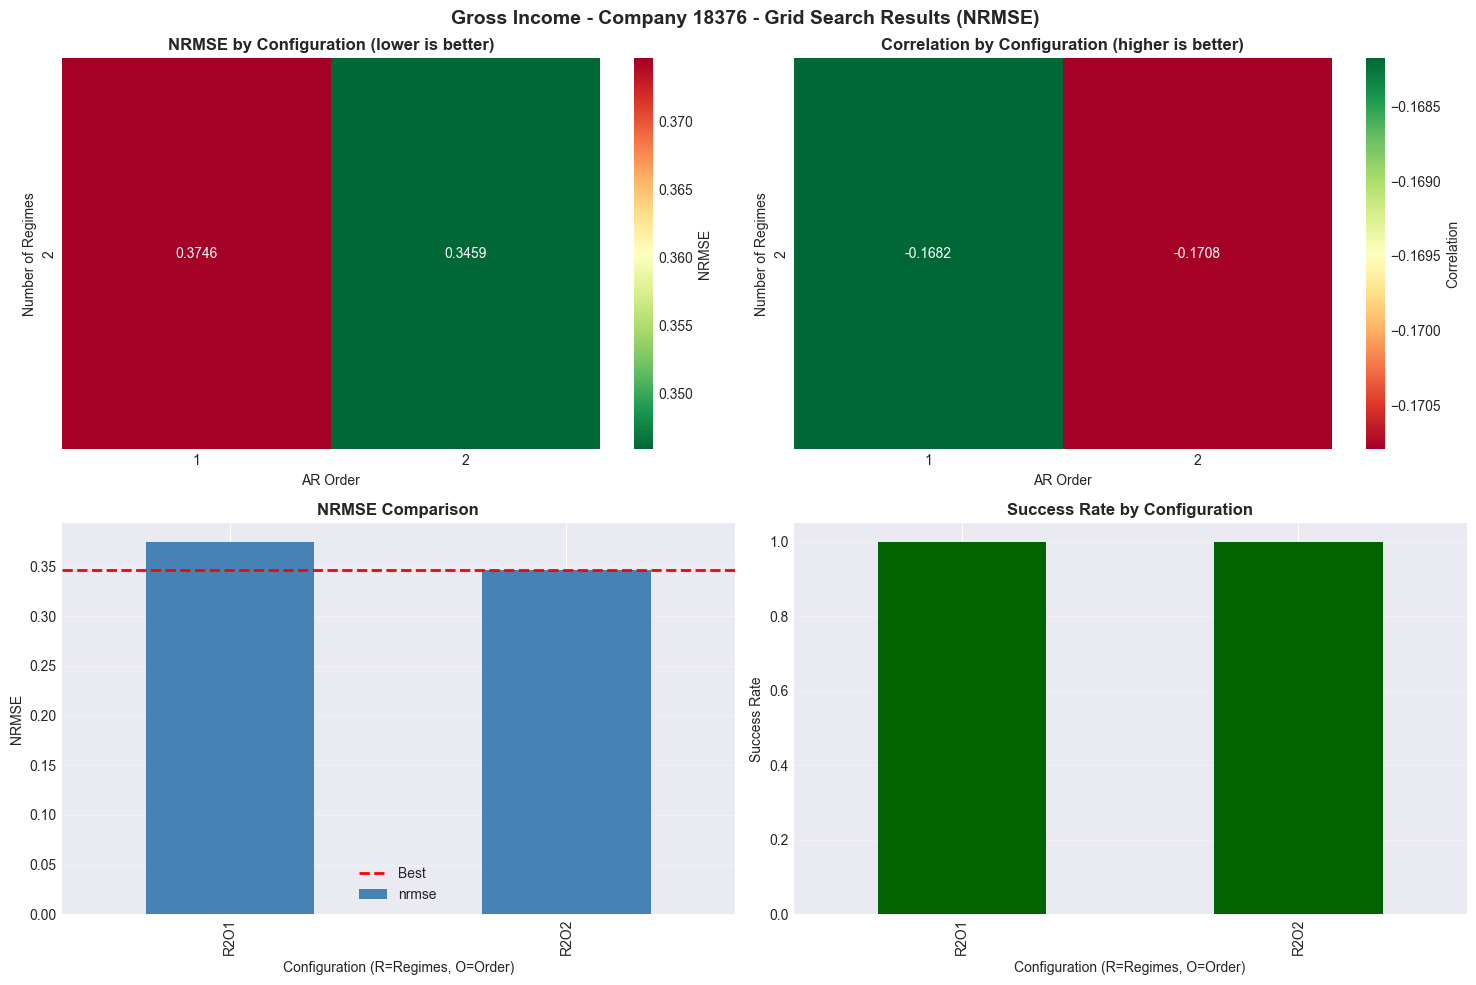


TABELA COMPLETA DE RESULTADOS
 k_regimes  order    nrmse     rmse      mae  correlacao  taxa_sucesso
         2      2 0.345912 0.883088 0.778537   -0.170792           1.0
         2      1 0.374633 0.956409 0.864272   -0.168180           1.0

=== Melhor Configuração ===
k_regimes: 2
order: 2
NRMSE: 0.3459


In [13]:
# Grid search baseado em NRMSE (validação one-step-ahead)
resultado_grid_nrmse = grid_search_ar_hmm_nrmse(
    serie=resultado_bruto[empresa_analise],
    nome_serie=f'Gross Income - Company {empresa_analise}',
    janela_treino=35,
    k_regimes_range=(2, 4),  # Testa 2 e 3 regimes
    order_range=(1, 3),       # Testa ordem 1 e 2
    usar_log_returns=True
)

if resultado_grid_nrmse is not None:
    print("\n=== Melhor Configuração ===")
    print(f"k_regimes: {int(resultado_grid_nrmse['melhor']['k_regimes'])}")
    print(f"order: {int(resultado_grid_nrmse['melhor']['order'])}")
    print(f"NRMSE: {resultado_grid_nrmse['melhor']['nrmse']:.4f}")


### 7.2 Grid Search para Todos os Indicadores e Empresas

Executa o grid search com NRMSE para todas as combinações de indicadores e empresas, armazenando os resultados em uma estrutura de dicionário para análise posterior.

In [126]:
# Preparação: Dicionário de indicadores
indicadores_dict = {
    'Gross Income': resultado_bruto,
    'Gross Profit': lucro_consolidado,
    'Operating Expenses': despesas_operacionais
}

# Lista de empresas (usar todas disponíveis ou filtrar)
empresas_list = resultado_bruto.columns.tolist()

# Opção: Filtrar apenas algumas empresas para teste rápido
# empresas_list = ['21490', '2437', '20257', '18376']

print(f"{'='*70}")
print("TREINAMENTO AR-HMM - TODOS OS INDICADORES E EMPRESAS")
print('='*70)
print(f"Indicadores: {list(indicadores_dict.keys())}")
print(f"Número de empresas: {len(empresas_list)}")
print(f"Total de combinações: {len(indicadores_dict) * len(empresas_list)}")
print(f"{'='*70}\n")

# Dicionário para armazenar todos os resultados
# Estrutura: resultados_ar_hmm[indicador][empresa] = resultado
resultados_ar_hmm = {}

# Contador de progresso
total_combinacoes = len(indicadores_dict) * len(empresas_list)
contador = 0
sucessos = 0
falhas = 0

# Loop principal: Indicadores -> Empresas
for nome_indicador, df_indicador in indicadores_dict.items():
    print(f"\n{'#'*70}")
    print(f"# INDICADOR: {nome_indicador}")
    print(f"{'#'*70}\n")
    
    # Inicializa dicionário do indicador
    resultados_ar_hmm[nome_indicador] = {}
    
    # Loop de empresas
    for empresa in empresas_list:
        contador += 1
        
        print(f"\n{'='*70}")
        print(f"[{contador}/{total_combinacoes}] {nome_indicador} - Company {empresa}")
        print('='*70)
        
        try:
            # Verifica se a série existe e tem dados suficientes
            if empresa not in df_indicador.columns:
                print(f"  ⚠ Empresa {empresa} não encontrada no indicador {nome_indicador}")
                resultados_ar_hmm[nome_indicador][empresa] = None
                falhas += 1
                continue
            
            serie = df_indicador[empresa]
            
            # Treina modelo AR-HMM
            resultado = treinar_ar_hmm(
                serie=serie,
                nome_serie=f'{nome_indicador} - Company {empresa}',
                k_regimes=3,
                order=1,
                em_iter=100,
                search_reps=10,
                usar_log_returns=True
            )
            
            # Armazena resultado
            resultados_ar_hmm[nome_indicador][empresa] = resultado
            
            if resultado is not None and resultado.get('convergiu', False):
                sucessos += 1
                print(f"\n  ✓ SUCESSO - Config: R{resultado['k_regimes']}O{resultado['order']} | AIC={resultado['aic']:.2f} | BIC={resultado['bic']:.2f}")
            else:
                falhas += 1
                print(f"\n  ✗ FALHA - Modelo não convergiu")
                
        except Exception as e:
            print(f"\n  ✗ ERRO: {e}")
            resultados_ar_hmm[nome_indicador][empresa] = None
            falhas += 1
            continue

# Resumo final
print(f"\n{'='*70}")
print("RESUMO FINAL DO TREINAMENTO")
print('='*70)
print(f"Total de combinações processadas: {contador}")
print(f"Sucessos: {sucessos} ({sucessos/contador*100:.1f}%)")
print(f"Falhas: {falhas} ({falhas/contador*100:.1f}%)")
print(f"{'='*70}\n")

TREINAMENTO AR-HMM - TODOS OS INDICADORES E EMPRESAS
Indicadores: ['Gross Income', 'Gross Profit', 'Operating Expenses']
Número de empresas: 4
Total de combinações: 12


######################################################################
# INDICADOR: Gross Income
######################################################################


[1/12] Gross Income - Company 2437

TRANSFORMAÇÃO PARA ESTACIONARIEDADE
Aplicando LOG RETURNS: r_t = log(y_t / y_(t-1))
⚠ Aviso: 1 valores não positivos encontrados
  Ajustando: somando constante para tornar todos positivos
  Observações antes: 59
  Observações depois: 58 (perde 1 observação)

--- Verificação de Estacionariedade (Série Transformada) ---
ADF p-value: 0.0000 ✓ estacionária
KPSS p-value: 0.0417 ✗ não estacionária
⚠ Aviso: Série transformada pode não ser totalmente estacionária

TREINAMENTO AR-HMM - Gross Income - Company 2437
Configuração:
  - Regimes: 3
  - Ordem AR: 1
  - Switching: trend=True, ar=True, variance=True
  - Observações: 58

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: Es

✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: 17.34
AIC: -4.69
BIC: 25.96

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                  17.345
Date:                  Tue, 10 Feb 2026   AIC                             -4.689
Time:                          20:52:32   BIC                             25.957
Sample:                               0   HQIC                             7.221
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

C:\Users\giova\AppData\Local\Temp\ipykernel_27904\3323454631.py:57: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_limpa, regression='c', nlags='auto')


✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: -17.43
AIC: 64.86
BIC: 95.51

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                 -17.431
Date:                  Tue, 10 Feb 2026   AIC                             64.862
Time:                          20:52:34   BIC                             95.508
Sample:                               0   HQIC                            76.772
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

...

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Li

✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: 8.50
AIC: 12.99
BIC: 43.64

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                   8.503
Date:                  Tue, 10 Feb 2026   AIC                             12.993
Time:                          20:52:47   BIC                             43.639
Sample:                               0   HQIC                            24.903
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: Es

✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: 12.34
AIC: 5.32
BIC: 35.97

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                  12.339
Date:                  Tue, 10 Feb 2026   AIC                              5.322
Time:                          20:52:49   BIC                             35.967
Sample:                               0   HQIC                            17.232
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
C:\Users\giova\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\regime_switching\markov_switching.py:1291: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'


### 7.3 Análise de Coincidência de Estados (Regimes)

**Análise em dois níveis:**
1. **Nível Micro (Empresa)**: Coincidência de estados entre diferentes indicadores da mesma empresa
2. **Nível Macro (Indicador)**: Coincidência de estados do mesmo indicador entre todas as empresas


ANÁLISE NÍVEL MICRO - COINCIDÊNCIA DE ESTADOS POR EMPRESA
Analisa quando TODOS os indicadores estão no MESMO estado simultaneamente

  ⚠ Empresa 20257: faltam indicadores Operating Expenses
  ⚠ Empresa 21490: faltam indicadores Operating Expenses

--- Estatísticas de Coincidência Micro (indicadores presentes) ---
Total de empresas analisadas: 4

Percentual médio de coincidência COMPLETA: 39.04%
Desvio padrão: 13.84%
Mínimo: 29.82%
Máximo: 59.65%

Obs: Coincidência COMPLETA = quando todos os indicadores PRESENTES estão no mesmo estado ao mesmo tempo

--- Top 10 Empresas com MAIOR Coincidência Completa ---
  20257 (2 ind.): 59.65% (34/57 momentos)
  2437 (3 ind.): 33.33% (19/57 momentos)
  21490 (2 ind.): 33.33% (19/57 momentos)
  18376 (3 ind.): 29.82% (17/57 momentos)

--- Top 10 Empresas com MENOR Coincidência Completa ---
  18376 (3 ind.): 29.82% (17/57 momentos)
  2437 (3 ind.): 33.33% (19/57 momentos)
  21490 (2 ind.): 33.33% (19/57 momentos)
  20257 (2 ind.): 59.65% (34/57 moment

,Empresa,Num_Indicadores,Coincidencias,Total_Observacoes,Percentual_Coincidencia
2,20257,2,34,57,59.649123
0,2437,3,19,57,33.333333
3,21490,2,19,57,33.333333
1,18376,3,17,57,29.824561



ANÁLISE NÍVEL MACRO - COINCIDÊNCIA DE ESTADOS POR INDICADOR
Analisa quando TODAS as empresas estão no MESMO estado simultaneamente


--- Estatísticas de Coincidência Macro (TODAS as empresas) ---
Total de indicadores analisados: 3

Gross Income:
  Número de empresas: 4
  Coincidência COMPLETA: 3.51%
  Momentos em sincronia: 2/57

Gross Profit:
  Número de empresas: 4
  Coincidência COMPLETA: 12.28%
  Momentos em sincronia: 7/57

Operating Expenses:
  Número de empresas: 2
  Coincidência COMPLETA: 49.12%
  Momentos em sincronia: 28/57

--- Ranking de Indicadores por Sincronização entre Empresas ---
  Operating Expenses: 49.12% (2 empresas)
  Gross Profit: 12.28% (4 empresas)
  Gross Income: 3.51% (4 empresas)

Obs: Coincidência COMPLETA = quando TODAS as empresas estão no mesmo estado ao mesmo tempo


,Indicador,Num_Empresas,Coincidencias,Total_Observacoes,Percentual_Coincidencia
2,Operating Expenses,2,28,57,49.122807
1,Gross Profit,4,7,57,12.280702
0,Gross Income,4,2,57,3.508772


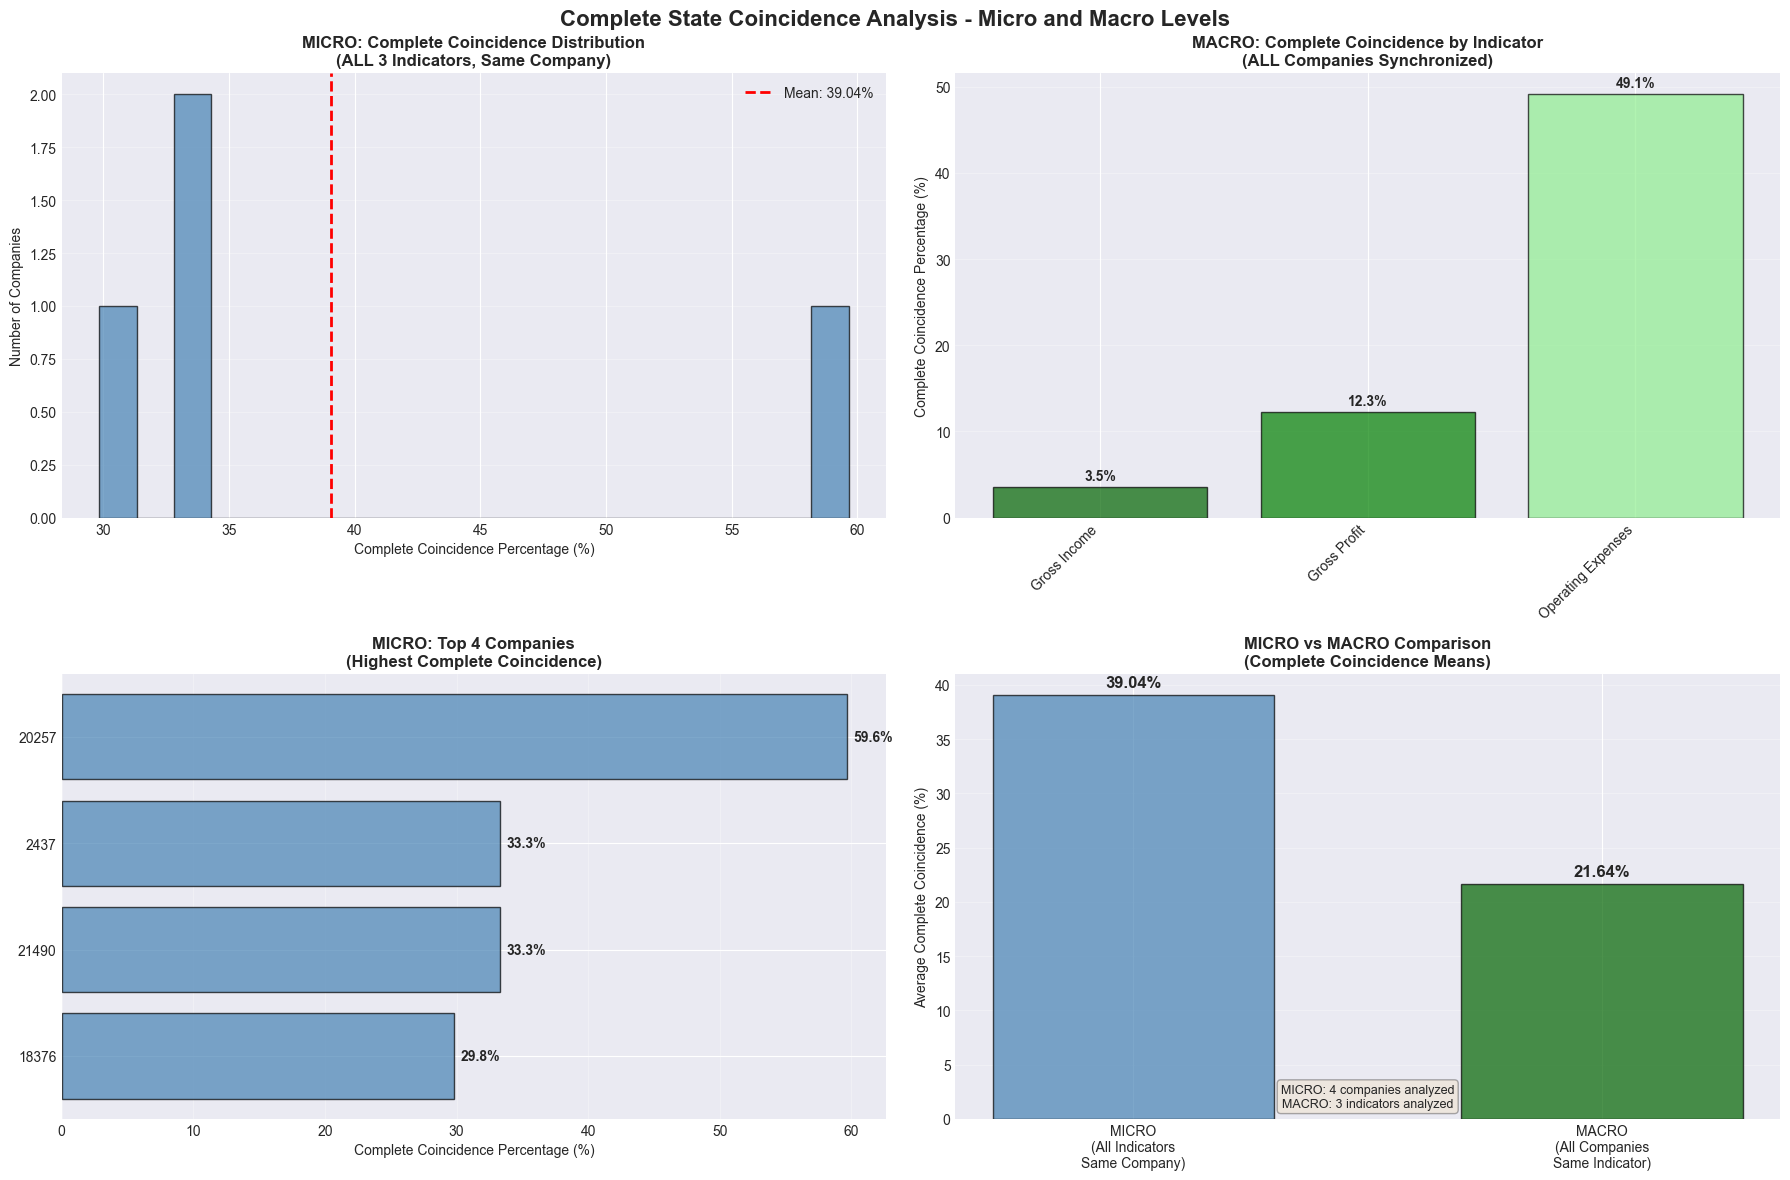


COMPARAÇÃO FINAL: MICRO vs MACRO

COINCIDÊNCIA COMPLETA (todos no mesmo estado simultaneamente):
  MICRO (todos os 3 indicadores, mesma empresa): 39.04%
  MACRO (todas as empresas, mesmo indicador): 21.64%

Diferença: 17.40 pontos percentuais

✓ CONCLUSÃO: Estados são MAIS coincidentes no nível MICRO
  → Dentro da mesma empresa, os 3 indicadores tendem a estar
    no mesmo estado simultaneamente com mais frequência
  → Sugere comportamento interno consistente/sincronizado entre indicadores

INTERPRETAÇÃO DOS RESULTADOS

Nível MICRO (39.04%):
  • Sincronização interna moderada - alguma consistência entre indicadores

Nível MACRO (21.64%):
  • Sincronização setorial moderada - algum efeito comum entre empresas


In [141]:
# ========== NÍVEL MICRO: Coincidência entre TODOS os indicadores da mesma empresa ==========

print(f"\n{'='*70}")
print("ANÁLISE NÍVEL MICRO - COINCIDÊNCIA DE ESTADOS POR EMPRESA")
print('='*70)
print("Analisa quando TODOS os indicadores estão no MESMO estado simultaneamente\n")

# Lista de indicadores
indicadores_lista = list(resultados_ar_hmm.keys())
num_indicadores = len(indicadores_lista)

# Dicionário para armazenar coincidências por empresa
coincidencias_micro = {}

# Processa cada empresa
for empresa in empresas_list:
    # Verifica se a empresa tem todos os indicadores
    estados_empresa = {}
    indicadores_faltantes = []
    
    for indicador in indicadores_lista:
        if empresa in resultados_ar_hmm[indicador]:
            resultado = resultados_ar_hmm[indicador][empresa]
            if resultado is not None and resultado.get('convergiu', False):
                # Pega os estados preditos (alinhados com o índice)
                estados_empresa[indicador] = resultado['estados_preditos']
            else:
                indicadores_faltantes.append(indicador)
        else:
            indicadores_faltantes.append(indicador)
    
    # Se faltam indicadores, registra no log
    if indicadores_faltantes:
        print(f"  ⚠ Empresa {empresa}: faltam indicadores {', '.join(indicadores_faltantes)}")
    
    # Calcula coincidência se tem pelo menos 2 indicadores
    if len(estados_empresa) >= 2:
        # Alinha os estados temporalmente (usa o menor tamanho comum)
        tamanho_min = min(len(estados) for estados in estados_empresa.values())
        
        # Trunca todos os arrays para o mesmo tamanho
        estados_alinhados = {ind: estados[:tamanho_min] for ind, estados in estados_empresa.items()}
        
        # Converte para DataFrame para facilitar comparação simultânea
        df_estados = pd.DataFrame(estados_alinhados)
        
        # Verifica quando TODOS os indicadores presentes têm o mesmo estado
        # Para cada linha (momento temporal), verifica se todos os valores são iguais
        todos_iguais = df_estados.apply(lambda row: len(set(row)) == 1, axis=1)
        
        coincidencias_total = todos_iguais.sum()
        total_observacoes = len(df_estados)
        percentual_total = (coincidencias_total / total_observacoes) * 100 if total_observacoes > 0 else 0
        
        coincidencias_micro[empresa] = {
            'coincidencias': coincidencias_total,
            'total': total_observacoes,
            'percentual': percentual_total,
            'num_indicadores': len(estados_empresa)
        }

# Cria DataFrame com resultados micro
dados_micro = []
for empresa, info in coincidencias_micro.items():
    dados_micro.append({
        'Empresa': empresa,
        'Num_Indicadores': info['num_indicadores'],
        'Coincidencias': info['coincidencias'],
        'Total_Observacoes': info['total'],
        'Percentual_Coincidencia': info['percentual']
    })

df_micro = pd.DataFrame(dados_micro)

if len(df_micro) > 0:
    print(f"\n--- Estatísticas de Coincidência Micro (indicadores presentes) ---")
    print(f"Total de empresas analisadas: {len(df_micro)}")
    print(f"\nPercentual médio de coincidência COMPLETA: {df_micro['Percentual_Coincidencia'].mean():.2f}%")
    print(f"Desvio padrão: {df_micro['Percentual_Coincidencia'].std():.2f}%")
    print(f"Mínimo: {df_micro['Percentual_Coincidencia'].min():.2f}%")
    print(f"Máximo: {df_micro['Percentual_Coincidencia'].max():.2f}%")
    print(f"\nObs: Coincidência COMPLETA = quando todos os indicadores PRESENTES estão no mesmo estado ao mesmo tempo")
    
    # Top 10 empresas com maior coincidência
    print(f"\n--- Top 10 Empresas com MAIOR Coincidência Completa ---")
    top_empresas = df_micro.nlargest(10, 'Percentual_Coincidencia')
    for idx, row in top_empresas.iterrows():
        print(f"  {row['Empresa']} ({row['Num_Indicadores']} ind.): {row['Percentual_Coincidencia']:.2f}% ({row['Coincidencias']}/{row['Total_Observacoes']} momentos)")
    
    # Bottom 10 empresas
    print(f"\n--- Top 10 Empresas com MENOR Coincidência Completa ---")
    bottom_empresas = df_micro.nsmallest(10, 'Percentual_Coincidencia')
    for idx, row in bottom_empresas.iterrows():
        print(f"  {row['Empresa']} ({row['Num_Indicadores']} ind.): {row['Percentual_Coincidencia']:.2f}% ({row['Coincidencias']}/{row['Total_Observacoes']} momentos)")
    
    display(df_micro.sort_values('Percentual_Coincidencia', ascending=False))
else:
    print("\n✗ Nenhuma coincidência micro calculada")

print(f"\n{'='*70}")
print("ANÁLISE NÍVEL MACRO - COINCIDÊNCIA DE ESTADOS POR INDICADOR")
print('='*70)
print("Analisa quando TODAS as empresas estão no MESMO estado simultaneamente\n")

# ========== NÍVEL MACRO: Coincidência entre TODAS as empresas do mesmo indicador ==========

coincidencias_macro = {}

for indicador in indicadores_lista:
    # Coleta estados de todas as empresas para este indicador
    estados_indicador = {}
    
    for empresa in empresas_list:
        if empresa in resultados_ar_hmm[indicador]:
            resultado = resultados_ar_hmm[indicador][empresa]
            if resultado is not None and resultado.get('convergiu', False):
                estados_indicador[empresa] = resultado['estados_preditos']
    
    # Só calcula se tem pelo menos 2 empresas
    if len(estados_indicador) >= 2:
        # Alinha temporalmente (usa o menor tamanho)
        tamanho_min = min(len(estados) for estados in estados_indicador.values())
        
        # Trunca todos os arrays para o mesmo tamanho
        estados_alinhados = {emp: estados[:tamanho_min] for emp, estados in estados_indicador.items()}
        
        # Converte para DataFrame para facilitar comparação simultânea
        df_estados = pd.DataFrame(estados_alinhados)
        
        # Verifica quando TODAS as empresas têm o mesmo estado
        # Para cada linha (momento temporal), verifica se todos os valores são iguais
        todos_iguais = df_estados.apply(lambda row: len(set(row)) == 1, axis=1)
        
        coincidencias_total = todos_iguais.sum()
        total_observacoes = len(df_estados)
        percentual_total = (coincidencias_total / total_observacoes) * 100 if total_observacoes > 0 else 0
        
        coincidencias_macro[indicador] = {
            'coincidencias': coincidencias_total,
            'total': total_observacoes,
            'percentual': percentual_total,
            'num_empresas': len(estados_indicador)
        }

# Cria DataFrame com resultados macro
dados_macro = []
for indicador, info in coincidencias_macro.items():
    dados_macro.append({
        'Indicador': indicador,
        'Num_Empresas': info['num_empresas'],
        'Coincidencias': info['coincidencias'],
        'Total_Observacoes': info['total'],
        'Percentual_Coincidencia': info['percentual']
    })

df_macro = pd.DataFrame(dados_macro)

if len(df_macro) > 0:
    print(f"\n--- Estatísticas de Coincidência Macro (TODAS as empresas) ---")
    print(f"Total de indicadores analisados: {len(df_macro)}")
    
    for _, row in df_macro.iterrows():
        print(f"\n{row['Indicador']}:")
        print(f"  Número de empresas: {row['Num_Empresas']}")
        print(f"  Coincidência COMPLETA: {row['Percentual_Coincidencia']:.2f}%")
        print(f"  Momentos em sincronia: {row['Coincidencias']}/{row['Total_Observacoes']}")
    
    print(f"\n--- Ranking de Indicadores por Sincronização entre Empresas ---")
    df_macro_sorted = df_macro.sort_values('Percentual_Coincidencia', ascending=False)
    for idx, row in df_macro_sorted.iterrows():
        print(f"  {row['Indicador']}: {row['Percentual_Coincidencia']:.2f}% ({row['Num_Empresas']} empresas)")
    
    print(f"\nObs: Coincidência COMPLETA = quando TODAS as empresas estão no mesmo estado ao mesmo tempo")
    
    display(df_macro.sort_values('Percentual_Coincidencia', ascending=False))
else:
    print("\n✗ Nenhuma coincidência macro calculada")

# ========== VISUALIZAÇÕES COMPARATIVAS ==========

if len(df_micro) > 0 or len(df_macro) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Complete State Coincidence Analysis - Micro and Macro Levels', fontsize=16, fontweight='bold')
    
    # 1. Distribuição Micro (todos os indicadores da mesma empresa)
    if len(df_micro) > 0:
        axes[0, 0].hist(df_micro['Percentual_Coincidencia'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        axes[0, 0].set_title(f'MICRO: Complete Coincidence Distribution\n(ALL {num_indicadores} Indicators, Same Company)', 
                            fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Complete Coincidence Percentage (%)')
        axes[0, 0].set_ylabel('Number of Companies')
        axes[0, 0].axvline(df_micro['Percentual_Coincidencia'].mean(), color='red', linestyle='--', 
                           linewidth=2, label=f'Mean: {df_micro["Percentual_Coincidencia"].mean():.2f}%')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Barplot Macro (todas as empresas do mesmo indicador)
    if len(df_macro) > 0:
        axes[0, 1].bar(range(len(df_macro)), df_macro['Percentual_Coincidencia'], 
                      color=['darkgreen', 'green', 'lightgreen'][:len(df_macro)], 
                      edgecolor='black', alpha=0.7)
        axes[0, 1].set_xticks(range(len(df_macro)))
        axes[0, 1].set_xticklabels(df_macro['Indicador'], rotation=45, ha='right')
        axes[0, 1].set_title(f'MACRO: Complete Coincidence by Indicator\n(ALL Companies Synchronized)', 
                            fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Complete Coincidence Percentage (%)')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # Adiciona valores no topo das barras
        for i, v in enumerate(df_macro['Percentual_Coincidencia']):
            axes[0, 1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 3. Top/Bottom empresas (Micro)
    if len(df_micro) > 0:
        top_n = min(10, len(df_micro))
        df_top = df_micro.nlargest(top_n, 'Percentual_Coincidencia')
        
        axes[1, 0].barh(range(len(df_top)), df_top['Percentual_Coincidencia'], 
                       color='steelblue', edgecolor='black', alpha=0.7)
        axes[1, 0].set_yticks(range(len(df_top)))
        axes[1, 0].set_yticklabels(df_top['Empresa'])
        axes[1, 0].set_title(f'MICRO: Top {top_n} Companies\n(Highest Complete Coincidence)', 
                           fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Complete Coincidence Percentage (%)')
        axes[1, 0].invert_yaxis()
        axes[1, 0].grid(True, alpha=0.3, axis='x')
        
        # Adiciona valores
        for i, v in enumerate(df_top['Percentual_Coincidencia']):
            axes[1, 0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')
    
    # 4. Comparação Micro vs Macro
    if len(df_micro) > 0 and len(df_macro) > 0:
        media_micro = df_micro['Percentual_Coincidencia'].mean()
        media_macro = df_macro['Percentual_Coincidencia'].mean()
        
        categorias = ['MICRO\n(All Indicators\nSame Company)', 'MACRO\n(All Companies\nSame Indicator)']
        valores = [media_micro, media_macro]
        cores = ['steelblue', 'darkgreen']
        
        bars = axes[1, 1].bar(categorias, valores, color=cores, edgecolor='black', alpha=0.7, width=0.6)
        axes[1, 1].set_title('MICRO vs MACRO Comparison\n(Complete Coincidence Means)', 
                           fontsize=12, fontweight='bold')
        axes[1, 1].set_ylabel('Average Complete Coincidence (%)')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        # Adiciona valores no topo
        for bar, val in zip(bars, valores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                          f'{val:.2f}%', ha='center', va='bottom', 
                          fontweight='bold', fontsize=12)
        
        # Adiciona informação adicional
        num_empresas_micro = len(df_micro)
        num_indicadores_macro = len(df_macro)
        axes[1, 1].text(0.5, 0.02, f'MICRO: {num_empresas_micro} companies analyzed\nMACRO: {num_indicadores_macro} indicators analyzed',
                       transform=axes[1, 1].transAxes, ha='center', va='bottom',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3), fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Comparação resumida
    print(f"\n{'='*70}")
    print("COMPARAÇÃO FINAL: MICRO vs MACRO")
    print('='*70)
    if len(df_micro) > 0 and len(df_macro) > 0:
        media_micro = df_micro['Percentual_Coincidencia'].mean()
        media_macro = df_macro['Percentual_Coincidencia'].mean()
        
        print(f"\nCOINCIDÊNCIA COMPLETA (todos no mesmo estado simultaneamente):")
        print(f"  MICRO (todos os {num_indicadores} indicadores, mesma empresa): {media_micro:.2f}%")
        print(f"  MACRO (todas as empresas, mesmo indicador): {media_macro:.2f}%")
        print(f"\nDiferença: {abs(media_micro - media_macro):.2f} pontos percentuais")
        
        if media_micro > media_macro:
            print("\n✓ CONCLUSÃO: Estados são MAIS coincidentes no nível MICRO")
            print(f"  → Dentro da mesma empresa, os {num_indicadores} indicadores tendem a estar")
            print("    no mesmo estado simultaneamente com mais frequência")
            print("  → Sugere comportamento interno consistente/sincronizado entre indicadores")
        else:
            print("\n✓ CONCLUSÃO: Estados são MAIS coincidentes no nível MACRO")            
            print("  → Entre diferentes empresas, o mesmo indicador tende a estar")
            print("    no mesmo estado simultaneamente com mais frequência")
            print("  → Sugere efeitos sistêmicos/macroeconômicos afetando empresas simultaneamente")
        
        # Interpretação adicional
        print(f"\n{'='*70}")
        print("INTERPRETAÇÃO DOS RESULTADOS")
        print('='*70)
        print(f"\nNível MICRO ({media_micro:.2f}%):")
        if media_micro < 20:
            print("  • Baixa sincronização interna - indicadores se comportam de forma independente")
        elif media_micro < 40:
            print("  • Sincronização interna moderada - alguma consistência entre indicadores")
        else:
            print("  • Alta sincronização interna - forte consistência entre indicadores da empresa")
        
        print(f"\nNível MACRO ({media_macro:.2f}%):")
        if media_macro < 20:
            print("  • Baixa sincronização setorial - empresas se comportam de forma independente")
        elif media_macro < 40:
            print("  • Sincronização setorial moderada - algum efeito comum entre empresas")
        else:
            print("  • Alta sincronização setorial - forte efeito sistêmico/macroeconômico")


## 8. Análise Comparativa: Múltiplas Empresas


ANÁLISE AR-HMM - Resultado Bruto - MÚLTIPLAS EMPRESAS

EMPRESA 21490

TRANSFORMAÇÃO PARA ESTACIONARIEDADE
Aplicando LOG RETURNS: r_t = log(y_t / y_(t-1))
  Observações antes: 59
  Observações depois: 58 (perde 1 observação)

--- Verificação de Estacionariedade (Série Transformada) ---
ADF p-value: 0.0000 ✓ estacionária
KPSS p-value: 0.1000 ✓ estacionária
✓✓ Série transformada é ESTACIONÁRIA (ambos os testes)

TREINAMENTO AR-HMM - Resultado Bruto - Empresa 21490
Configuração:
  - Regimes: 2
  - Ordem AR: 1
  - Switching: trend=True, ar=True, variance=True
  - Observações: 58

Iniciando ajuste... (pode levar alguns minutos)


C:\Users\giova\AppData\Local\Temp\ipykernel_27904\3323454631.py:57: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_limpa, regression='c', nlags='auto')


✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: 12.22
AIC: -8.44
BIC: 7.90

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                  12.222
Date:                  Tue, 10 Feb 2026   AIC                             -8.444
Time:                          21:08:52   BIC                              7.900
Sample:                               0   HQIC                            -2.092
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

C:\Users\giova\AppData\Local\Temp\ipykernel_27904\3323454631.py:57: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(serie_limpa, regression='c', nlags='auto')


✓ Modelo convergiu com sucesso!

--- Critérios de Ajuste ---
Log-Likelihood: -23.31
AIC: 62.61
BIC: 78.96

--- Parâmetros Estimados por Regime ---

                         Markov Switching Model Results                         
Dep. Variable:                        y   No. Observations:                   57
Model:             MarkovAutoregression   Log Likelihood                 -23.307
Date:                  Tue, 10 Feb 2026   AIC                             62.613
Time:                          21:08:54   BIC                             78.958
Sample:                               0   HQIC                            68.965
                                   - 57                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

""


KeyError: 'empresa'

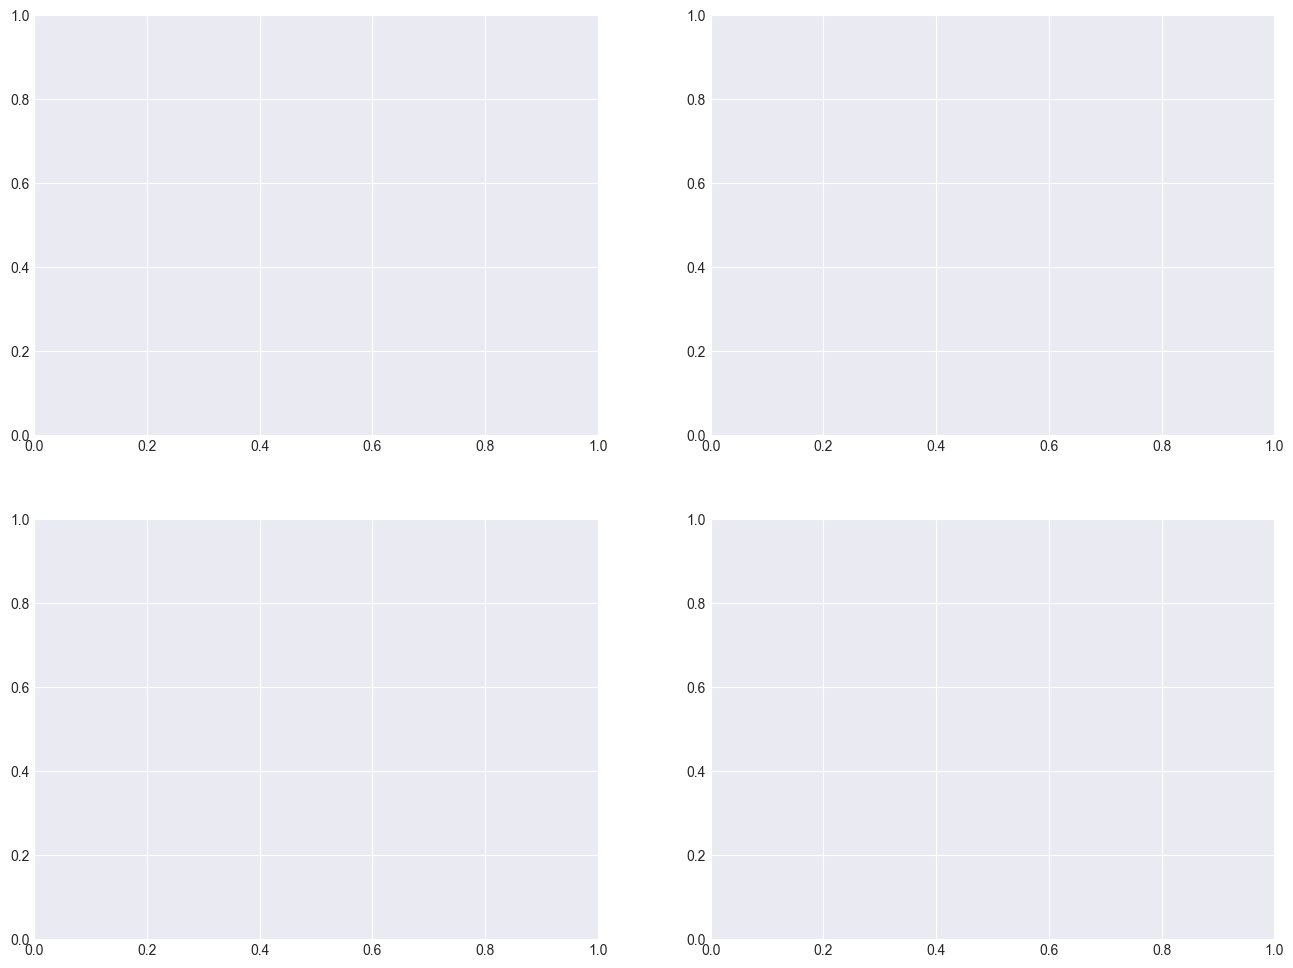

In [133]:
def analisar_multiplas_empresas_ar_hmm(empresas_list, indicador_series, nome_indicador,
                                       k_regimes=2, order=1):
    """
    Treina AR-HMM para múltiplas empresas e compara resultados
    """
    print(f"\n{'='*70}")
    print(f"ANÁLISE AR-HMM - {nome_indicador} - MÚLTIPLAS EMPRESAS")
    print('='*70)
    
    resultados_empresas = {}
    resumo_comparativo = []
    
    for empresa in empresas_list:
        print(f"\n{'='*70}")
        print(f"EMPRESA {empresa}")
        print('='*70)
        
        try:
            serie = indicador_series[empresa]
            resultado = treinar_ar_hmm(
                serie=serie,
                nome_serie=f'{nome_indicador} - Empresa {empresa}',
                k_regimes=k_regimes,
                order=order,
                em_iter=30,
                search_reps=10
            )
            
            if resultado is not None:
                resultados_empresas[empresa] = resultado
                
                # Extrai parâmetros para comparação
                modelo = resultado['modelo']
                try:
                    if isinstance(modelo.params, pd.Series):
                        for regime in range(k_regimes):
                            resumo_comparativo.append({
                                'empresa': empresa,
                                'regime': regime,
                                'intercepto': modelo.params[f'const[{regime}]'],
                                'phi': modelo.params[f'y.L1[{regime}]'],
                                'sigma2': modelo.params[f'sigma2[{regime}]'],
                                'aic': resultado['aic'],
                                'bic': resultado['bic']
                            })
                except (KeyError, IndexError) as e:
                    print(f"⚠ Erro ao extrair parâmetros da empresa {empresa}: {e}")
        
        except Exception as e:
            print(f"✗ Erro na empresa {empresa}: {e}")
            continue
    
    if not resultados_empresas:
        print("Nenhuma empresa processada com sucesso!")
        return None
    
    # Resumo comparativo
    df_resumo = pd.DataFrame(resumo_comparativo)
    
    print(f"\n{'='*70}")
    print("RESUMO COMPARATIVO DOS PARÂMETROS")
    print('='*70)
    display(df_resumo)
    
    # Visualização comparativa
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Comparação de φ (persistência)
    df_pivot_phi = df_resumo.pivot(index='empresa', columns='regime', values='phi')
    df_pivot_phi.plot(kind='bar', ax=axes[0, 0], color=['crimson', 'navy'])
    axes[0, 0].set_title('AR Coefficient (φ) by Company and Regime', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('φ (Persistence)')
    axes[0, 0].legend(title='Regime')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
    
    # Comparação de σ² (volatilidade)
    df_pivot_sigma = df_resumo.pivot(index='empresa', columns='regime', values='sigma2')
    df_pivot_sigma.plot(kind='bar', ax=axes[0, 1], color=['orange', 'green'])
    axes[0, 1].set_title('Variance (σ²) by Company and Regime', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('σ² (Volatility)')
    axes[0, 1].legend(title='Regime')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Comparação de AIC
    df_aic = df_resumo.groupby('empresa')['aic'].first()
    df_aic.plot(kind='bar', ax=axes[1, 0], color='steelblue')
    axes[1, 0].set_title('AIC by Company', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('AIC')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Comparação de BIC
    df_bic = df_resumo.groupby('empresa')['bic'].first()
    df_bic.plot(kind='bar', ax=axes[1, 1], color='darkgreen')
    axes[1, 1].set_title('BIC by Company', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('BIC')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'resultados_empresas': resultados_empresas,
        'resumo_comparativo': df_resumo
    }

# Análise comparativa
empresas_analise = ['21490', '2437', '20257', '18376']
resultado_comparativo = analisar_multiplas_empresas_ar_hmm(
    empresas_list=empresas_analise,
    indicador_series=resultado_bruto,
    nome_indicador='Resultado Bruto',
    k_regimes=2,
    order=1
)

## 9. Comparação: AR-HMM vs GaussianHMM

In [ ]:
# Este bloco pode ser usado para comparar AR-HMM com GaussianHMM do notebook anterior
# Mostrando as vantagens do AR-HMM em capturar autocorrelação

print("""
╔═══════════════════════════════════════════════════════════════════════╗
║                    AR-HMM vs GaussianHMM Tradicional                  ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  GAUSSIANHMM TRADICIONAL:                                            ║
║  • Emissões: y_t ~ N(μ_s(t), σ²_s(t))                               ║
║  • Observações INDEPENDENTES dentro de cada regime                   ║
║  • Não captura autocorrelação temporal                               ║
║                                                                       ║
║  AR-HMM (MARKOV SWITCHING AUTOREGRESSION):                          ║
║  • Emissões: y_t = μ_s(t) + φ_s(t) * y_{t-1} + ε_t                 ║
║  • Observações DEPENDENTES (processo autoregressivo)                 ║
║  • Captura autocorrelação e persistência por regime                  ║
║                                                                       ║
║  VANTAGENS DO AR-HMM PARA INDICADORES CONTÁBEIS:                    ║
║  ✓ Realista: indicadores têm inércia (não mudam abruptamente)       ║
║  ✓ Interpretável: φ > 0.8 → crescimento persistente                 ║
║                   φ < 0.2 → reversão rápida à média                 ║
║  ✓ Previsão: usa valor anterior para prever próximo                 ║
║  ✓ Detecção de regimes: identifica mudanças de dinâmica             ║
║                                                                       ║
║  QUANDO USAR CADA UM:                                                ║
║  • GaussianHMM: Séries sem autocorrelação forte                     ║
║  • AR-HMM: Séries com ACF(1) > 0.2 (indicadores contábeis típicos) ║
║                                                                       ║
╚═══════════════════════════════════════════════════════════════════════╝
""")

## 10. Conclusões e Próximos Passos

### Principais Descobertas

O modelo **AR-HMM (Markov Switching Autoregression)** oferece vantagens significativas sobre HMM tradicional:

1. **Captura Autocorrelação**: Indicadores contábeis têm inércia natural
2. **Interpretabilidade**: Coeficiente φ indica persistência vs reversão
3. **Previsão Realista**: Usa valor anterior (memória)
4. **Regimes com Dinâmicas Distintas**: Cada regime tem seu próprio comportamento AR

### Interpretação dos Parâmetros

- **φ (Persistência)**:
  - φ > 0.8: Shocks persistentes (crescimento/crise prolongada)
  - 0.5 < φ < 0.8: Memória moderada
  - φ < 0.2: Reversão rápida à média
  
- **σ² (Volatilidade)**:
  - Alto σ²: Incerteza, difícil previsão
  - Baixo σ²: Estabilidade, previsibilidade

- **μ (Intercepto)**:
  - Nível base do indicador em cada regime

### Próximos Passos

1. ✅ Comparar com benchmarks (ARIMA, Prophet)
2. ✅ Testar ordem AR(2) ou AR(3)
3. ✅ Incorporar variáveis exógenas (índices econômicos)
4. ✅ Análise de eventos (relacionar transições com crises)
5. ✅ Validação out-of-sample em períodos específicos
6. ✅ Análise de sensibilidade dos parâmetros

### Referências

- Hamilton, J. D. (1989). "A New Approach to the Economic Analysis of Nonstationary Time Series and the Business Cycle"
- Kim, C. J., & Nelson, C. R. (1999). "State-Space Models with Regime Switching"
- Statsmodels Documentation: Markov Switching Models